<a href="https://colab.research.google.com/github/2000030914/2000030914/blob/main/SOLVING_PART_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

DATASET_ROOT = Path("/content/drive/MyDrive")
T2_ROOT = DATASET_ROOT / "Cirrhosis_T2_3D"

print("Dataset root exists:", DATASET_ROOT.exists())
print("T2 folder exists:", T2_ROOT.exists())
print("T2 path:", T2_ROOT)

Dataset root exists: True
T2 folder exists: False
T2 path: /content/drive/MyDrive/Cirrhosis_T2_3D


In [2]:
from pathlib import Path

T2_ROOT = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D"
)

print("=" * 80)
print("REAL T2_3D DATA ROOT")
print("=" * 80)
print("Exists:", T2_ROOT.exists())
print("Path:", T2_ROOT)

print("\nDIRECT CONTENTS")
print("=" * 80)

for item in sorted(T2_ROOT.iterdir()):
    if item.is_dir():
        print("[FOLDER]", item.name)
    else:
        print("[FILE]  ", item.name)

REAL T2_3D DATA ROOT
Exists: True
Path: /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D

DIRECT CONTENTS
[FOLDER] test_images
[FOLDER] test_masks
[FOLDER] train_images
[FOLDER] train_masks
[FOLDER] valid_images
[FOLDER] valid_masks


In [3]:
METADATA_ROOT = Path("/content/drive/MyDrive/CirrMRI_dataset/Metadata")

print("=" * 80)
print("METADATA ROOT")
print("=" * 80)
print("Exists:", METADATA_ROOT.exists())

for item in sorted(METADATA_ROOT.iterdir()):
    if item.is_dir():
        print("[FOLDER]", item.name)
    else:
        print("[FILE]  ", item.name)

METADATA ROOT
Exists: True
[FILE]   CirrMRI600+_CompleteData_age_gender_evaluation.csv
[FILE]   Healthy_demographics.csv
[FILE]   T1&T2_Paired_age_gender_evaluation.csv
[FILE]   T1_age_gender_evaluation.csv
[FILE]   T2_age_gender_evaluation.csv
[FILE]   labels.txt


In [4]:
from pathlib import Path

T2_ROOT = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D"
)

for split in ["train", "valid", "test"]:
    print("\n" + "=" * 70)
    print(split.upper())

    image_dir = T2_ROOT / f"{split}_images"
    mask_dir = T2_ROOT / f"{split}_masks"

    images = sorted([
        p for p in image_dir.iterdir()
        if p.is_file()
    ])

    masks = sorted([
        p for p in mask_dir.iterdir()
        if p.is_file()
    ])

    print("Images:", len(images))
    print("Masks :", len(masks))

    print("\nExample image files:")
    for p in images[:5]:
        print(" ", p.name)

    print("\nExample mask files:")
    for p in masks[:5]:
        print(" ", p.name)


TRAIN
Images: 256
Masks : 256

Example image files:
  10.nii.gz
  100.nii.gz
  102.nii.gz
  103.nii.gz
  105.nii.gz

Example mask files:
  10.nii.gz
  100.nii.gz
  102.nii.gz
  103.nii.gz
  105.nii.gz

VALID
Images: 31
Masks : 31

Example image files:
  393.nii.gz
  472.nii.gz
  479.nii.gz
  48.nii.gz
  481.nii.gz

Example mask files:
  393.nii.gz
  472.nii.gz
  479.nii.gz
  48.nii.gz
  481.nii.gz

TEST
Images: 31
Masks : 31

Example image files:
  58.nii.gz
  60.nii.gz
  62.nii.gz
  63.nii.gz
  64.nii.gz

Example mask files:
  58.nii.gz
  60.nii.gz
  62.nii.gz
  63.nii.gz
  64.nii.gz


In [5]:
import pandas as pd

META = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/Metadata/"
    "CirrMRI600+_CompleteData_age_gender_evaluation.csv"
)

df = pd.read_csv(META)

print("=" * 70)
print("METADATA")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nFirst 10 rows:")
display(df.head(10))

METADATA
Shape: (337, 4)

Columns:
0 : Patient ID
1 : Age
2 : Gender
3 : Radiological Evaluation

First 10 rows:


,Patient ID,Age,Gender,Radiological Evaluation
0,3,28,2,3
1,4,60,2,3
2,5,61,1,1
3,8,63,2,3
4,9,49,2,3
5,10,51,2,3
6,12,53,2,1
7,13,62,2,1
8,17,80,2,3
9,18,75,2,2


In [6]:
import pandas as pd
from pathlib import Path

META = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/Metadata/"
    "CirrMRI600+_CompleteData_age_gender_evaluation.csv"
)

df = pd.read_csv(META)

print("=" * 80)
print("RADIOLOGICAL EVALUATION")
print("=" * 80)

print(df["Radiological Evaluation"].value_counts(dropna=False).sort_index())

print("\nUnique labels:")
print(sorted(df["Radiological Evaluation"].dropna().unique()))

print("\nPatient ID statistics")
print("Total rows:", len(df))
print("Unique Patient IDs:", df["Patient ID"].nunique())
print("Duplicate Patient IDs:",
      df["Patient ID"].duplicated().sum())

print("\nAge range:",
      df["Age"].min(), "-", df["Age"].max())

print("\nGender distribution:")
print(df["Gender"].value_counts(dropna=False))

print("\nComplete metadata:")
display(df)

RADIOLOGICAL EVALUATION
Radiological Evaluation
1    137
2    116
3     84
Name: count, dtype: int64

Unique labels:
[np.int64(1), np.int64(2), np.int64(3)]

Patient ID statistics
Total rows: 337
Unique Patient IDs: 337
Duplicate Patient IDs: 0

Age range: 20 - 92

Gender distribution:
Gender
2    204
1    133
Name: count, dtype: int64

Complete metadata:


,Patient ID,Age,Gender,Radiological Evaluation
0,3,28,2,3
1,4,60,2,3
2,5,61,1,1
3,8,63,2,3
4,9,49,2,3
...,...,...,...,...
332,507,38,1,2
333,509,66,1,3
334,510,61,1,3
335,511,64,1,1


In [7]:
import re

def file_id(path):
    name = Path(path).name
    if name.endswith(".nii.gz"):
        return int(name[:-7])
    elif name.endswith(".nii"):
        return int(name[:-4])
    return None

for split in ["train", "valid", "test"]:

    image_dir = T2_ROOT / f"{split}_images"

    ids = sorted([
        file_id(p)
        for p in image_dir.iterdir()
        if p.is_file() and
        (p.name.endswith(".nii") or p.name.endswith(".nii.gz"))
    ])

    metadata_matches = df[df["Patient ID"].isin(ids)]

    print("\n" + "=" * 70)
    print(split.upper())

    print("T2 files:", len(ids))
    print("Unique T2 IDs:", len(set(ids)))
    print("Metadata matches:", len(metadata_matches))

    missing_metadata = sorted(set(ids) - set(df["Patient ID"]))
    print("T2 IDs without metadata:", len(missing_metadata))

    if missing_metadata:
        print("Examples:", missing_metadata[:20])


TRAIN
T2 files: 256
Unique T2 IDs: 256
Metadata matches: 256
T2 IDs without metadata: 0

VALID
T2 files: 31
Unique T2 IDs: 31
Metadata matches: 31
T2 IDs without metadata: 0

TEST
T2 files: 31
Unique T2 IDs: 31
Metadata matches: 31
T2 IDs without metadata: 0


In [8]:
from pathlib import Path

LABEL_FILE = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/Metadata/labels.txt"
)

print("=" * 70)
print("LABEL DEFINITIONS")
print("=" * 70)

print(LABEL_FILE.read_text())

LABEL DEFINITIONS
Gender:
1 = Female
2 = Male

Radiological Evaluation:
1 = Mild
2 = Moderate
3 = Severe



In [9]:
print("=" * 70)
print("TEST SET SEVERITY DISTRIBUTION")
print("=" * 70)

test_ids = []

test_dir = T2_ROOT / "test_images"

for p in test_dir.iterdir():
    if p.name.endswith(".nii.gz"):
        test_ids.append(int(p.name[:-7]))
    elif p.name.endswith(".nii"):
        test_ids.append(int(p.name[:-4]))

test_df = df[df["Patient ID"].isin(test_ids)].copy()

print("Test cases:", len(test_df))
print(test_df["Radiological Evaluation"].value_counts().sort_index())

print("\nTest cases by label:")
display(
    test_df[
        ["Patient ID", "Age", "Gender", "Radiological Evaluation"]
    ].sort_values("Patient ID")
)

TEST SET SEVERITY DISTRIBUTION
Test cases: 31
Radiological Evaluation
1    16
2     6
3     9
Name: count, dtype: int64

Test cases by label:


,Patient ID,Age,Gender,Radiological Evaluation
3,8,63,2,3
4,9,49,2,3
37,58,64,1,2
38,60,63,1,1
39,62,42,1,1
40,63,76,2,3
41,64,65,2,1
42,65,63,1,1
43,68,63,1,2
44,69,50,1,3


In [11]:
import os
import torch
import nibabel as nib
import numpy as np
import pandas as pd

print("=" * 70)
print("ENVIRONMENT CHECK")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

print("NumPy   :", np.__version__)
print("Pandas  :", pd.__version__)
print("NiBabel :", nib.__version__)

# Dataset
ROOT = "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D"

print("\n" + "=" * 70)
print("DATASET CHECK")
print("=" * 70)
print("ROOT exists:", os.path.exists(ROOT))

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(ROOT, f"{split}_images")
    mask_dir = os.path.join(ROOT, f"{split}_masks")

    imgs = [f for f in os.listdir(img_dir)
            if f.endswith(".nii") or f.endswith(".nii.gz")]
    masks = [f for f in os.listdir(mask_dir)
             if f.endswith(".nii") or f.endswith(".nii.gz")]

    print(f"\n{split.upper()}")
    print("Images:", len(imgs))
    print("Masks :", len(masks))

ENVIRONMENT CHECK
PyTorch : 2.11.0+cpu
CUDA    : False
NumPy   : 2.1.3
Pandas  : 2.2.3
NiBabel : 5.4.2

DATASET CHECK
ROOT exists: True

TRAIN
Images: 256
Masks : 256

VALID
Images: 31
Masks : 31

TEST
Images: 31
Masks : 31


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

# Force a small computation on GPU
if torch.cuda.is_available():
    x = torch.randn(3000, 3000, device="cuda")
    y = x @ x
    torch.cuda.synchronize()
    print("GPU computation successful!")
    print("Allocated GPU memory:", round(torch.cuda.memory_allocated() / 1024**2, 2), "MB")

import os
import nibabel as nib
import numpy as np

ROOT = "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D"

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(ROOT, f"{split}_images")
    mask_dir = os.path.join(ROOT, f"{split}_masks")

    images = sorted([
        f for f in os.listdir(img_dir)
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ])

    masks = sorted([
        f for f in os.listdir(mask_dir)
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ])

    print(f"{split}: images={len(images)}, masks={len(masks)}")

img_file = sorted([
    f for f in os.listdir(os.path.join(ROOT, "train_images"))
    if f.endswith(".nii") or f.endswith(".nii.gz")
])[0]

mask_file = sorted([
    f for f in os.listdir(os.path.join(ROOT, "train_masks"))
    if f.endswith(".nii") or f.endswith(".nii.gz")
])[0]

img = nib.load(os.path.join(ROOT, "train_images", img_file))
mask = nib.load(os.path.join(ROOT, "train_masks", mask_file))

print("\nExample:")
print("Image:", img_file)
print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", img.get_fdata(dtype=np.float32).dtype)
print("Mask unique:", np.unique(mask.get_fdata()))


import os
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

ROOT = "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D"
CACHE = "/content/cirr_t2_2d_cache"

os.makedirs(CACHE, exist_ok=True)

TARGET_H = 256
TARGET_W = 256

def get_files(split):
    img_dir = os.path.join(ROOT, f"{split}_images")
    mask_dir = os.path.join(ROOT, f"{split}_masks")

    imgs = sorted([
        f for f in os.listdir(img_dir)
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ])

    masks = sorted([
        f for f in os.listdir(mask_dir)
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ])

    return imgs, masks


def preprocess_volume(img_path, mask_path):
    img = nib.load(img_path).get_fdata(dtype=np.float32)
    mask = nib.load(mask_path).get_fdata(dtype=np.float32)

    images_out = []
    masks_out = []

    for z in range(img.shape[2]):
        x = img[:, :, z]
        y = mask[:, :, z]

        if np.max(x) > np.min(x):
            lo, hi = np.percentile(x, [1, 99])
            x = np.clip(x, lo, hi)

        fg = x[x > 0]

        if len(fg) > 10:
            mean = fg.mean()
            std = fg.std()
            if std > 1e-6:
                x = (x - mean) / std

        x = torch.from_numpy(x).float()[None, None]
        y = torch.from_numpy((y > 0).astype(np.float32))[None, None]

        x = F.interpolate(
            x,
            size=(TARGET_H, TARGET_W),
            mode="bilinear",
            align_corners=False
        )

        y = F.interpolate(
            y,
            size=(TARGET_H, TARGET_W),
            mode="nearest"
        )

        images_out.append(x[0, 0].numpy().astype(np.float16))
        masks_out.append(y[0, 0].numpy().astype(np.uint8))

    return np.stack(images_out), np.stack(masks_out)


for split in ["train", "valid", "test"]:

    imgs, masks = get_files(split)

    print(f"\n{split.upper()} volumes: {len(imgs)}")

    volume_cache = []
    total_slices = 0

    for img_name, mask_name in tqdm(
        zip(imgs, masks),
        total=len(imgs),
        desc=f"Processing {split}"
    ):
        img_path = os.path.join(ROOT, f"{split}_images", img_name)
        mask_path = os.path.join(ROOT, f"{split}_masks", mask_name)

        img_arr, mask_arr = preprocess_volume(img_path, mask_path)

        volume_cache.append((img_arr, mask_arr))
        total_slices += img_arr.shape[0]

    image_file = os.path.join(CACHE, f"{split}_images.dat")
    mask_file = os.path.join(CACHE, f"{split}_masks.dat")

    images_mm = np.memmap(
        image_file,
        dtype=np.float16,
        mode="w+",
        shape=(total_slices, TARGET_H, TARGET_W)
    )

    masks_mm = np.memmap(
        mask_file,
        dtype=np.uint8,
        mode="w+",
        shape=(total_slices, TARGET_H, TARGET_W)
    )

    pos = 0

    for img_arr, mask_arr in volume_cache:
        n = img_arr.shape[0]

        images_mm[pos:pos+n] = img_arr
        masks_mm[pos:pos+n] = mask_arr

        pos += n

    images_mm.flush()
    masks_mm.flush()

    del images_mm
    del masks_mm
    del volume_cache

    np.save(
        os.path.join(CACHE, f"{split}_shape.npy"),
        np.array([total_slices, TARGET_H, TARGET_W])
    )

    print(f"{split}: {total_slices} slices cached")


print("\nCACHE CREATED")
print(CACHE)

for f in sorted(os.listdir(CACHE)):
    print(f)

import os
import numpy as np
import torch

CACHE = "/content/cirr_t2_2d_cache"

TARGET_H = 256
TARGET_W = 256

def load_cache(split):
    shape = np.load(
        os.path.join(CACHE, f"{split}_shape.npy")
    )

    n = int(shape[0])

    images = np.memmap(
        os.path.join(CACHE, f"{split}_images.dat"),
        dtype=np.float16,
        mode="r",
        shape=(n, TARGET_H, TARGET_W)
    )

    masks = np.memmap(
        os.path.join(CACHE, f"{split}_masks.dat"),
        dtype=np.uint8,
        mode="r",
        shape=(n, TARGET_H, TARGET_W)
    )

    return images, masks


train_images, train_masks = load_cache("train")
valid_images, valid_masks = load_cache("valid")
test_images, test_masks = load_cache("test")

print("Train:", train_images.shape, train_masks.shape)
print("Valid:", valid_images.shape, valid_masks.shape)
print("Test :", test_images.shape, test_masks.shape)

print("\nMemory-mapped cache loaded successfully.")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (CPU mode)")

from torch.utils.data import Dataset, DataLoader
import numpy as np

class LiverSliceDataset(Dataset):
    def __init__(self, images, masks, augment=False):
        self.images = images
        self.masks = masks
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = np.asarray(self.images[idx], dtype=np.float32)
        mask = np.asarray(self.masks[idx], dtype=np.float32)

        if self.augment:

            if np.random.rand() < 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()

            if np.random.rand() < 0.25:
                scale = np.random.uniform(0.95, 1.05)
                image = image * scale

            if np.random.rand() < 0.20:
                noise = np.random.normal(
                    0,
                    0.02,
                    image.shape
                ).astype(np.float32)

                image = image + noise

        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask


train_dataset = LiverSliceDataset(
    train_images,
    train_masks,
    augment=True
)

valid_dataset = LiverSliceDataset(
    valid_images,
    valid_masks,
    augment=False
)

test_dataset = LiverSliceDataset(
    test_images,
    test_masks,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

x, y = next(iter(train_loader))

print("Image batch:", x.shape)
print("Mask batch :", y.shape)
print("Image dtype:", x.dtype)
print("Mask dtype :", y.dtype)
print("Image range:", x.min().item(), x.max().item())
print("Mask values:", torch.unique(y))
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        hidden = max(channels // reduction, 4)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        mx = self.mlp(self.max_pool(x))

        attention = self.sigmoid(avg + mx)

        return x * attention


class MultiScaleDilatedContext(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.branch1 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            dilation=1,
            bias=False
        )

        self.branch2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=2,
            dilation=2,
            bias=False
        )

        self.branch3 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=4,
            dilation=4,
            bias=False
        )

        self.bn = nn.BatchNorm2d(channels * 3)

        self.fusion = nn.Conv2d(
            channels * 3,
            channels,
            kernel_size=1,
            bias=False
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)

        out = torch.cat([b1, b2, b3], dim=1)

        out = self.bn(out)
        out = self.relu(out)

        out = self.fusion(out)
        out = self.relu(out)

        return out


class GatedSkipFusion(nn.Module):
    def __init__(self, skip_channels, decoder_channels):
        super().__init__()

        self.skip_proj = nn.Conv2d(
            skip_channels,
            decoder_channels,
            kernel_size=1,
            bias=False
        )

        self.gate = nn.Sequential(
            nn.Conv2d(
                decoder_channels * 2,
                decoder_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                decoder_channels,
                decoder_channels,
                kernel_size=1
            ),
            nn.Sigmoid()
        )

    def forward(self, skip, decoder):

        skip = self.skip_proj(skip)

        if skip.shape[-2:] != decoder.shape[-2:]:
            skip = F.interpolate(
                skip,
                size=decoder.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        combined = torch.cat([skip, decoder], dim=1)

        gate = self.gate(combined)

        skip = skip * gate

        return torch.cat([skip, decoder], dim=1)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.gated_skip = GatedSkipFusion(
            skip_channels,
            out_channels
        )

        self.conv = ResidualBlock(
            out_channels * 2,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        x = self.gated_skip(skip, x)

        x = self.conv(x)

        return x


class BAMR_UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.enc1 = ResidualBlock(
            in_channels,
            32
        )

        self.enc2 = ResidualBlock(
            32,
            64
        )

        self.enc3 = ResidualBlock(
            64,
            128
        )

        self.enc4 = ResidualBlock(
            128,
            256
        )

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ResidualBlock(
            256,
            512
        )

        self.context = MultiScaleDilatedContext(512)

        self.attention = ChannelAttention(512)

        self.dec4 = DecoderBlock(
            512,
            256,
            256
        )

        self.dec3 = DecoderBlock(
            256,
            128,
            128
        )

        self.dec2 = DecoderBlock(
            128,
            64,
            64
        )

        self.dec1 = DecoderBlock(
            64,
            32,
            32
        )

        self.seg_head = nn.Conv2d(
            32,
            out_channels,
            kernel_size=1
        )

        self.boundary_head = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

        self.deep_head2 = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

        self.deep_head3 = nn.Conv2d(
            128,
            1,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        b = self.bottleneck(
            self.pool(e4)
        )

        b = self.context(b)

        b = self.attention(b)

        d4 = self.dec4(b, e4)

        d3 = self.dec3(d4, e3)

        d2 = self.dec2(d3, e2)

        d1 = self.dec1(d2, e1)

        segmentation = self.seg_head(d1)

        boundary = self.boundary_head(d1)

        deep2 = self.deep_head2(d2)
        deep2 = F.interpolate(
            deep2,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        deep3 = self.deep_head3(d3)
        deep3 = F.interpolate(
            deep3,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        return {
            "segmentation": segmentation,
            "boundary": boundary,
            "deep2": deep2,
            "deep3": deep3
        }


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = BAMR_UNet(
    in_channels=1,
    out_channels=1
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (CPU mode)")

print(f"Trainable parameters: {total_params:,}")

test_input = torch.randn(
    2,
    1,
    256,
    256,
    device=device
)

with torch.no_grad():
    test_output = model(test_input)

print("\nOutput shapes:")

for key, value in test_output.items():
    print(key, value.shape)
import torch
import torch.nn as nn
import torch.nn.functional as F


def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)

    probs = probs.contiguous().view(probs.size(0), -1)
    targets = targets.contiguous().view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return 1.0 - dice.mean()


def boundary_target(mask):
    dilated = F.max_pool2d(
        mask,
        kernel_size=3,
        stride=1,
        padding=1
    )

    eroded = 1.0 - F.max_pool2d(
        1.0 - mask,
        kernel_size=3,
        stride=1,
        padding=1
    )

    boundary = dilated - eroded

    return (boundary > 0).float()


bce_loss = nn.BCEWithLogitsLoss()


def combined_loss(outputs, target):

    seg_logits = outputs["segmentation"]
    boundary_logits = outputs["boundary"]
    deep2_logits = outputs["deep2"]
    deep3_logits = outputs["deep3"]

    loss_seg_dice = dice_loss(
        seg_logits,
        target
    )

    loss_seg_bce = bce_loss(
        seg_logits,
        target
    )

    target_boundary = boundary_target(target)

    loss_boundary = bce_loss(
        boundary_logits,
        target_boundary
    )

    loss_deep2 = dice_loss(
        deep2_logits,
        target
    )

    loss_deep3 = dice_loss(
        deep3_logits,
        target
    )

    total = (
        0.50 * loss_seg_dice
        + 0.20 * loss_seg_bce
        + 0.20 * loss_boundary
        + 0.10 * (0.5 * loss_deep2 + 0.5 * loss_deep3)
    )

    return total


# Loss sanity check
model.eval()

with torch.no_grad():
    x_test = torch.randn(
        2, 1, 256, 256,
        device=device
    )

    y_test = torch.randint(
        0, 2,
        (2, 1, 256, 256),
        device=device
    ).float()

    outputs_test = model(x_test)

    loss_test = combined_loss(
        outputs_test,
        y_test
    )

print("Loss sanity check:", float(loss_test))
print("Loss is finite:", torch.isfinite(loss_test).item())
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

model = BAMR_UNet(
    in_channels=1,
    out_channels=1
).to(device)

print("Fresh BAMR-UNet V2 initialization complete.")
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm


# ============================================================
# BAMR-UNet V2 TRAINING
# ============================================================

NUM_EPOCHS = 30
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 8

MODEL_DIR = "/content/cirr_t2_models"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "BAMR_UNet_T2_V2_best.pth"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)


# ============================================================
# FIXED DATA LOADERS FOR COLAB
# ============================================================

train_loader_v2 = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader_v2 = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ============================================================
# IMPROVED LOSS
# ============================================================

def soft_dice_loss(logits, targets, smooth=1e-6):

    probs = torch.sigmoid(logits)

    probs = probs.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        probs * targets
    ).sum(dim=1)

    dice = (
        2.0 * intersection + smooth
    ) / (
        probs.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return 1.0 - dice.mean()


def tversky_loss(
    logits,
    targets,
    alpha=0.3,
    beta=0.7,
    smooth=1e-6
):

    probs = torch.sigmoid(logits)

    probs = probs.flatten(1)
    targets = targets.flatten(1)

    true_positive = (
        probs * targets
    ).sum(dim=1)

    false_positive = (
        probs * (1.0 - targets)
    ).sum(dim=1)

    false_negative = (
        (1.0 - probs) * targets
    ).sum(dim=1)

    tversky = (
        true_positive + smooth
    ) / (
        true_positive
        + alpha * false_positive
        + beta * false_negative
        + smooth
    )

    return 1.0 - tversky.mean()


bce_loss = nn.BCEWithLogitsLoss()


def create_boundary_target(mask):

    dilated = F.max_pool2d(
        mask,
        kernel_size=3,
        stride=1,
        padding=1
    )

    eroded = 1.0 - F.max_pool2d(
        1.0 - mask,
        kernel_size=3,
        stride=1,
        padding=1
    )

    boundary = dilated - eroded

    return (boundary > 0).float()


def bamr_v2_loss(outputs, target):

    segmentation = outputs["segmentation"]
    boundary = outputs["boundary"]
    deep2 = outputs["deep2"]
    deep3 = outputs["deep3"]

    loss_dice = soft_dice_loss(
        segmentation,
        target
    )

    loss_tversky = tversky_loss(
        segmentation,
        target,
        alpha=0.3,
        beta=0.7
    )

    loss_bce = bce_loss(
        segmentation,
        target
    )

    boundary_target = create_boundary_target(
        target
    )

    loss_boundary = bce_loss(
        boundary,
        boundary_target
    )

    loss_deep2 = soft_dice_loss(
        deep2,
        target
    )

    loss_deep3 = soft_dice_loss(
        deep3,
        target
    )

    loss_deep = (
        0.5 * loss_deep2
        + 0.5 * loss_deep3
    )

    total_loss = (
        0.35 * loss_dice
        + 0.25 * loss_tversky
        + 0.15 * loss_bce
        + 0.15 * loss_boundary
        + 0.10 * loss_deep
    )

    return total_loss


# ============================================================
# METRICS
# ============================================================

def batch_metrics(logits, targets, threshold=0.5):

    probs = torch.sigmoid(logits)

    preds = (
        probs >= threshold
    ).float()

    preds_flat = preds.flatten(1)
    targets_flat = targets.flatten(1)

    intersection = (
        preds_flat * targets_flat
    ).sum(dim=1)

    pred_sum = preds_flat.sum(dim=1)
    target_sum = targets_flat.sum(dim=1)

    dice = (
        2.0 * intersection + 1e-6
    ) / (
        pred_sum
        + target_sum
        + 1e-6
    )

    union = (
        pred_sum
        + target_sum
        - intersection
    )

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return (
        dice.mean().item(),
        iou.mean().item()
    )


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# COSINE LEARNING RATE
# ============================================================

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)


# ============================================================
# MIXED PRECISION
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)


# ============================================================
# HISTORY
# ============================================================

history_v2 = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": [],
    "lr": []
}


best_val_dice = -1.0
epochs_without_improvement = 0


# ============================================================
# TRAINING
# ============================================================

print("Starting BAMR-UNet V2 training")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (CPU mode)")

print("Train slices:", len(train_dataset))
print("Validation slices:", len(valid_dataset))
print("Epochs:", NUM_EPOCHS)
print("Batch size:", train_loader_v2.batch_size)
print("Learning rate:", LEARNING_RATE)
print()


for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss_sum = 0.0
    train_dice_sum = 0.0
    train_iou_sum = 0.0
    train_batches = 0

    train_bar = tqdm(
        train_loader_v2,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]",
        leave=False
    )

    for images, masks in train_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = bamr_v2_loss(
                outputs,
                masks
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)

        scaler.update()

        dice, iou = batch_metrics(
            outputs["segmentation"],
            masks
        )

        train_loss_sum += loss.item()
        train_dice_sum += dice
        train_iou_sum += iou
        train_batches += 1

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{dice:.4f}"
        )


    train_loss = (
        train_loss_sum / train_batches
    )

    train_dice = (
        train_dice_sum / train_batches
    )

    train_iou = (
        train_iou_sum / train_batches
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss_sum = 0.0
    val_dice_sum = 0.0
    val_iou_sum = 0.0
    val_batches = 0

    with torch.no_grad():

        val_bar = tqdm(
            valid_loader_v2,
            desc=f"Epoch {epoch}/{NUM_EPOCHS} [Valid]",
            leave=False
        )

        for images, masks in val_bar:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):

                outputs = model(images)

                loss = bamr_v2_loss(
                    outputs,
                    masks
                )

            dice, iou = batch_metrics(
                outputs["segmentation"],
                masks
            )

            val_loss_sum += loss.item()
            val_dice_sum += dice
            val_iou_sum += iou
            val_batches += 1


    val_loss = (
        val_loss_sum / val_batches
    )

    val_dice = (
        val_dice_sum / val_batches
    )

    val_iou = (
        val_iou_sum / val_batches
    )


    # ========================================================
    # LEARNING RATE
    # ========================================================

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]


    # ========================================================
    # HISTORY
    # ========================================================

    history_v2["train_loss"].append(
        train_loss
    )

    history_v2["val_loss"].append(
        val_loss
    )

    history_v2["train_dice"].append(
        train_dice
    )

    history_v2["val_dice"].append(
        val_dice
    )

    history_v2["train_iou"].append(
        train_iou
    )

    history_v2["val_iou"].append(
        val_iou
    )

    history_v2["lr"].append(
        current_lr
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    if val_dice > best_val_dice:

        best_val_dice = val_dice

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou,
                "history": history_v2
            },
            BEST_MODEL_PATH
        )

        best_marker = "  <-- BEST"

    else:

        epochs_without_improvement += 1

        best_marker = ""


    # ========================================================
    # REPORT
    # ========================================================

    elapsed = time.time() - epoch_start

    print(
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Train IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed/60:.2f} min"
        f"{best_marker}"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


print("\nBAMR-UNet V2 training complete.")

print(
    f"Best validation Dice: "
    f"{best_val_dice:.4f}"
)

print(
    "Best V2 model saved to:"
)

print(
    BEST_MODEL_PATH
)


PyTorch version: 2.11.0+cpu
CUDA available: False
GPU: None
train: images=256, masks=256
valid: images=31, masks=31
test: images=31, masks=31

Example:
Image: 10.nii.gz
Image shape: (320, 260, 35)
Mask shape: (320, 260, 35)
Image dtype: float32
Mask unique: [0. 1.]

TRAIN volumes: 256


Processing train:   0%|          | 0/256 [00:00<?, ?it/s]

train: 9356 slices cached

VALID volumes: 31


Processing valid:   0%|          | 0/31 [00:00<?, ?it/s]

valid: 1167 slices cached

TEST volumes: 31


...

test: 1179 slices cached

CACHE CREATED
/content/cirr_t2_2d_cache
test_images.dat
test_masks.dat
test_shape.npy
train_images.dat
train_masks.dat
train_shape.npy
valid_images.dat
valid_masks.dat
valid_shape.npy
Train: (9356, 256, 256) (9356, 256, 256)
Valid: (1167, 256, 256) (1167, 256, 256)
Test : (1179, 256, 256) (1179, 256, 256)

Memory-mapped cache loaded successfully.
GPU: None (CPU mode)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch: torch.Size([16, 1, 256, 256])
Mask batch : torch.Size([16, 1, 256, 256])
Image dtype: torch.float32
Mask dtype : torch.float32
Image range: -1.671875 3.453125
Mask values: tensor([0., 1.])
Device: cpu
GPU: None (CPU mode)
Trainable parameters: 16,396,356

Output shapes:
segmentation torch.Size([2, 1, 256, 256])
boundary torch.Size([2, 1, 256, 256])
deep2 torch.Size([2, 1, 256, 256])
deep3 torch.Size([2, 1, 256, 256])
Loss sanity check: 0.5882304310798645
Loss is finite: True
Fresh BAMR-UNet V2 initialization complete.
Starting BAMR-UNet V2 training
Device: cpu
GPU: None (CPU mode)
Train slices: 9356
Validation slices: 1167
Epochs: 30
Batch size: 16
Learning rate: 3e-05



/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/30 [Train]:   0%|          | 0/585 [00:00<?, ?it/s]

In [13]:
import os
import shutil

DRIVE_MODEL_DIR = "/content/drive/MyDrive/CirrMRI_project_models"
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

src = "/content/cirr_t2_models/BAMR_UNet_T2_V2_best.pth"

dst = os.path.join(
    DRIVE_MODEL_DIR,
    "BAMR_UNet_T2_V2_best_epoch26.pth"
)

shutil.copy2(src, dst)

print("V2 best model saved successfully.")
print(dst)

print(
    "File size:",
    round(os.path.getsize(dst) / (1024**2), 2),
    "MB"
)
# ============================================================
# FINAL T2 TEST EVALUATION
# BAMR-UNet V2
# Dice / IoU / Precision / Recall / Specificity
# HD95 / ASSD in millimeters
# 95% Bootstrap Confidence Intervals
# ============================================================

import os
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt, binary_erosion
from tqdm.auto import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

TEST_IMG_DIR = "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images"

TEST_MASK_DIR = "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_masks"

MODEL_PATH = "/content/drive/MyDrive/CirrMRI_project_models/BAMR_UNet_T2_V2_best_epoch26.pth"

OUTPUT_DIR = "/content/drive/MyDrive/CirrMRI_project_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "BAMR_UNet_T2_V2_test_volume_metrics.csv"
)

SUMMARY_PATH = os.path.join(
    OUTPUT_DIR,
    "BAMR_UNet_T2_V2_test_summary.csv"
)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model = BAMR_UNet().to(device)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    model.load_state_dict(checkpoint)

model.float()
model.eval()

print("Model loaded successfully.")

# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

def preprocess_slice(
    slice_img,
    target_size=(256, 256)
):

    slice_img = slice_img.astype(
        np.float32
    )

    nonzero = slice_img[
        slice_img > 0
    ]

    if len(nonzero) > 0:

        p1 = np.percentile(
            nonzero,
            1
        )

        p99 = np.percentile(
            nonzero,
            99
        )

        slice_img = np.clip(
            slice_img,
            p1,
            p99
        )

        foreground = slice_img > 0

        if np.any(foreground):

            mean = slice_img[
                foreground
            ].mean()

            std = slice_img[
                foreground
            ].std()

            slice_img[foreground] = (
                slice_img[foreground] - mean
            ) / (std + 1e-8)

    tensor = torch.from_numpy(
        slice_img
    ).float()

    tensor = tensor.unsqueeze(
        0
    ).unsqueeze(
        0
    )

    tensor = F.interpolate(
        tensor,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    return tensor

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def dice_score(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        pred,
        target
    ).sum()

    denominator = (
        pred.sum() +
        target.sum()
    )

    if denominator == 0:
        return 1.0

    return (
        2.0 * intersection
    ) / denominator


def iou_score(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    intersection = np.logical_and(
        pred,
        target
    ).sum()

    union = np.logical_or(
        pred,
        target
    ).sum()

    if union == 0:
        return 1.0

    return intersection / union


def precision_score(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    tp = np.logical_and(
        pred,
        target
    ).sum()

    fp = np.logical_and(
        pred,
        ~target
    ).sum()

    return tp / (
        tp + fp + 1e-8
    )


def recall_score(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    tp = np.logical_and(
        pred,
        target
    ).sum()

    fn = np.logical_and(
        ~pred,
        target
    ).sum()

    return tp / (
        tp + fn + 1e-8
    )


def specificity_score(pred, target):

    pred = pred.astype(bool)
    target = target.astype(bool)

    tn = np.logical_and(
        ~pred,
        ~target
    ).sum()

    fp = np.logical_and(
        pred,
        ~target
    ).sum()

    return tn / (
        tn + fp + 1e-8
    )

# ------------------------------------------------------------
# SURFACE DISTANCES IN MILLIMETERS
# ------------------------------------------------------------

def surface_distances(
    mask_a,
    mask_b,
    spacing
):

    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)

    if (
        not mask_a.any()
        or not mask_b.any()
    ):
        return np.array([])

    surface_a = (
        mask_a ^
        binary_erosion(mask_a)
    )

    surface_b = (
        mask_b ^
        binary_erosion(mask_b)
    )

    distance_b = distance_transform_edt(
        ~mask_b,
        sampling=spacing
    )

    distance_a = distance_transform_edt(
        ~mask_a,
        sampling=spacing
    )

    distances_a_to_b = (
        distance_b[surface_a]
    )

    distances_b_to_a = (
        distance_a[surface_b]
    )

    return np.concatenate([
        distances_a_to_b,
        distances_b_to_a
    ])


def hd95_mm(
    pred,
    target,
    spacing
):

    distances = surface_distances(
        pred,
        target,
        spacing
    )

    if len(distances) == 0:
        return np.nan

    return np.percentile(
        distances,
        95
    )


def assd_mm(
    pred,
    target,
    spacing
):

    distances = surface_distances(
        pred,
        target,
        spacing
    )

    if len(distances) == 0:
        return np.nan

    return np.mean(distances)

# ------------------------------------------------------------
# CHECK TEST FILES
# ------------------------------------------------------------

image_files = sorted([
    f
    for f in os.listdir(TEST_IMG_DIR)
    if f.endswith(".nii.gz")
])

mask_files = sorted([
    f
    for f in os.listdir(TEST_MASK_DIR)
    if f.endswith(".nii.gz")
])

assert len(image_files) == len(mask_files)

for img_name, mask_name in zip(
    image_files,
    mask_files
):

    assert img_name == mask_name, (
        f"Image/mask mismatch: "
        f"{img_name} vs {mask_name}"
    )

print(
    "Test volumes:",
    len(image_files)
)

print(
    "Image/mask pairing verified."
)

# ------------------------------------------------------------
# TEST EVALUATION
# ------------------------------------------------------------

results = []

for filename in tqdm(
    image_files,
    desc="Evaluating test volumes"
):

    img_path = os.path.join(
        TEST_IMG_DIR,
        filename
    )

    mask_path = os.path.join(
        TEST_MASK_DIR,
        filename
    )

    img_nii = nib.load(
        img_path
    )

    mask_nii = nib.load(
        mask_path
    )

    image = img_nii.get_fdata().astype(
        np.float32
    )

    target = mask_nii.get_fdata().astype(
        np.float32
    )

    spacing = tuple(
        float(x)
        for x in img_nii.header.get_zooms()[:3]
    )

    assert image.shape == target.shape

    H, W, Z = image.shape

    prediction = np.zeros(
        (H, W, Z),
        dtype=np.uint8
    )

    # --------------------------------------------------------
    # SLICE-WISE INFERENCE
    # --------------------------------------------------------

    with torch.no_grad():

        for z in range(Z):

            input_tensor = preprocess_slice(
                image[:, :, z]
            )

            input_tensor = (
                input_tensor
                .to(device)
                .float()
            )

            output = model(
                input_tensor
            )

            # BAMR-UNet returns a dictionary

            if isinstance(
                output,
                dict
            ):

                segmentation = (
                    output["segmentation"]
                )

            elif isinstance(
                output,
                (tuple, list)
            ):

                segmentation = output[0]

            else:

                segmentation = output

            segmentation = segmentation.float()

            probability = torch.sigmoid(
                segmentation
            )

            pred_slice = (
                probability[0, 0]
                .cpu()
                .numpy()
            )

            pred_slice = (
                pred_slice >= 0.5
            ).astype(
                np.uint8
            )

            # Resize prediction back
            # to original H x W

            pred_tensor = torch.from_numpy(
                pred_slice.astype(
                    np.float32
                )
            )

            pred_tensor = (
                pred_tensor
                .unsqueeze(0)
                .unsqueeze(0)
            )

            pred_tensor = F.interpolate(
                pred_tensor,
                size=(H, W),
                mode="nearest"
            )

            prediction[:, :, z] = (
                pred_tensor[0, 0]
                .numpy()
                .astype(np.uint8)
            )

    # --------------------------------------------------------
    # TARGET
    # --------------------------------------------------------

    target_binary = (
        target >= 0.5
    ).astype(np.uint8)

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    dice = dice_score(
        prediction,
        target_binary
    )

    iou = iou_score(
        prediction,
        target_binary
    )

    precision = precision_score(
        prediction,
        target_binary
    )

    recall = recall_score(
        prediction,
        target_binary
    )

    specificity = specificity_score(
        prediction,
        target_binary
    )

    hd95 = hd95_mm(
        prediction,
        target_binary,
        spacing
    )

    assd = assd_mm(
        prediction,
        target_binary,
        spacing
    )

    results.append({

        "case":
            filename.replace(
                ".nii.gz",
                ""
            ),

        "dice":
            dice,

        "iou":
            iou,

        "precision":
            precision,

        "recall":
            recall,

        "specificity":
            specificity,

        "hd95_mm":
            hd95,

        "assd_mm":
            assd,

        "spacing_x_mm":
            spacing[0],

        "spacing_y_mm":
            spacing[1],

        "spacing_z_mm":
            spacing[2],

        "shape_x":
            H,

        "shape_y":
            W,

        "shape_z":
            Z
    })

# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame(
    results
)

df.to_csv(
    CSV_PATH,
    index=False
)

print()
print(
    "Saved per-volume results:"
)

print(CSV_PATH)

# ------------------------------------------------------------
# MEAN ± SD
# ------------------------------------------------------------

metric_columns = [

    "dice",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95_mm",
    "assd_mm"
]

print()
print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

for metric in metric_columns:

    values = (
        df[metric]
        .dropna()
        .values
    )

    mean = np.mean(values)

    std = np.std(
        values,
        ddof=1
    )

    if metric in [
        "dice",
        "iou",
        "precision",
        "recall",
        "specificity"
    ]:

        print(
            f"{metric:15s}: "
            f"{mean:.4f} ± {std:.4f} "
            f"({mean*100:.2f}% ± "
            f"{std*100:.2f}%)"
        )

    else:

        print(
            f"{metric:15s}: "
            f"{mean:.4f} ± "
            f"{std:.4f} mm"
        )

# ------------------------------------------------------------
# BOOTSTRAP 95% CI
# ------------------------------------------------------------

def bootstrap_ci(
    values,
    n_bootstrap=1000,
    seed=42
):

    values = np.asarray(
        values
    )

    values = values[
        ~np.isnan(values)
    ]

    rng = np.random.default_rng(
        seed
    )

    bootstrap_means = []

    for _ in range(
        n_bootstrap
    ):

        sample = rng.choice(
            values,
            size=len(values),
            replace=True
        )

        bootstrap_means.append(
            np.mean(sample)
        )

    lower = np.percentile(
        bootstrap_means,
        2.5
    )

    upper = np.percentile(
        bootstrap_means,
        97.5
    )

    return lower, upper

# ------------------------------------------------------------
# CONFIDENCE INTERVALS
# ------------------------------------------------------------

print()
print("=" * 70)
print("95% BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 70)

ci_results = []

for metric in metric_columns:

    values = (
        df[metric]
        .dropna()
        .values
    )

    mean = np.mean(
        values
    )

    lower, upper = bootstrap_ci(
        values,
        n_bootstrap=1000,
        seed=42
    )

    ci_results.append({

        "metric":
            metric,

        "mean":
            mean,

        "ci_lower":
            lower,

        "ci_upper":
            upper
    })

    if metric in [
        "dice",
        "iou",
        "precision",
        "recall",
        "specificity"
    ]:

        print(
            f"{metric:15s}: "
            f"{mean:.4f} "
            f"[{lower:.4f}, "
            f"{upper:.4f}]"
        )

    else:

        print(
            f"{metric:15s}: "
            f"{mean:.4f} mm "
            f"[{lower:.4f}, "
            f"{upper:.4f}] mm"
        )

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

summary_df = pd.DataFrame(
    ci_results
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print()
print(
    "Saved summary:"
)

print(
    SUMMARY_PATH
)

# ------------------------------------------------------------
# DISPLAY PER-VOLUME RESULTS
# ------------------------------------------------------------

print()
print("Per-volume results:")

display(
    df[
        [
            "case",
            "dice",
            "iou",
            "precision",
            "recall",
            "specificity",
            "hd95_mm",
            "assd_mm"
        ]
    ].round(4)
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/cirr_t2_models/BAMR_UNet_T2_V2_best.pth'

In [14]:
# ============================================================
# CHECKPOINT PATH CORRECTION / FINAL VERIFICATION
# ============================================================

import os

CHECKPOINT = (
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/"
    "BAMR_UNet_T2_V2_best_epoch22.pth"
)

print("=" * 70)
print("CORRECTED CHECKPOINT VERIFICATION")
print("=" * 70)

print("Checkpoint:")
print(CHECKPOINT)
print("Exists:", os.path.exists(CHECKPOINT))

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"Verified checkpoint not found:\n{CHECKPOINT}"
    )

file_size_mb = os.path.getsize(CHECKPOINT) / (1024 * 1024)

print(f"File size: {file_size_mb:.2f} MB")
print()
print("Checkpoint status: VERIFIED")
print("Training required: NO")
print("Using previously trained Epoch-22 model: YES")
print("=" * 70)

CORRECTED CHECKPOINT VERIFICATION
Checkpoint:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_best_epoch22.pth
Exists: True
File size: 187.88 MB

Checkpoint status: VERIFIED
Training required: NO
Using previously trained Epoch-22 model: YES


In [ ]:
import torch
from pathlib import Path

CKPT = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/BAMR_UNet_T2_V2_best_epoch26.pth"
)

print("=" * 80)
print("CHECKPOINT VERIFICATION")
print("=" * 80)

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)

print("File:", CKPT.name)
print("Exists:", CKPT.exists())
print("Epoch stored:", ckpt.get("epoch"))
print("Validation Dice stored:", ckpt.get("val_dice"))
print("Validation IoU stored:", ckpt.get("val_iou"))

history = ckpt.get("history")

print("\nHistory type:", type(history))

if history is not None:
    if isinstance(history, dict):
        print("History keys:", history.keys())
        for k, v in history.items():
            if hasattr(v, "__len__"):
                print(f"{k}: {len(v)} values")

    elif isinstance(history, (list, tuple)):
        print("History length:", len(history))
        print("First entry:", history[0] if len(history) else None)
        print("Last entry :", history[-1] if len(history) else None)

CHECKPOINT VERIFICATION
File: BAMR_UNet_T2_V2_best_epoch26.pth
Exists: True
Epoch stored: 22
Validation Dice stored: 0.8957232424657638
Validation IoU stored: 0.8658871969131574

History type: <class 'dict'>
History keys: dict_keys(['train_loss', 'val_loss', 'train_dice', 'val_dice', 'train_iou', 'val_iou', 'lr'])
train_loss: 22 values
val_loss: 22 values
train_dice: 22 values
val_dice: 22 values
train_iou: 22 values
val_iou: 22 values
lr: 22 values


In [ ]:
from pathlib import Path
import shutil

old = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/BAMR_UNet_T2_V2_best_epoch26.pth"
)

new = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/BAMR_UNet_T2_V2_best_epoch22.pth"
)

shutil.copy2(old, new)

print("OLD :", old.name)
print("NEW :", new.name)
print("Exists:", new.exists())

OLD : BAMR_UNet_T2_V2_best_epoch26.pth
NEW : BAMR_UNet_T2_V2_best_epoch22.pth
Exists: True


In [ ]:
from pathlib import Path
import shutil

# ============================================================
# SAVE / FREEZE OBJECTIVE-1 RESULTS
# ============================================================

MODEL_SRC = Path(
    "/content/drive/MyDrive/CirrMRI_project_models/"
    "BAMR_UNet_T2_V2_best_epoch26.pth"
)

RESULT_SRC = Path(
    "/content/drive/MyDrive/CirrMRI_project_results"
)

FINAL_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation"
)

FINAL_DIR.mkdir(parents=True, exist_ok=True)

files_to_save = [
    MODEL_SRC,
    RESULT_SRC / "BAMR_UNet_T2_V2_test_volume_metrics.csv",
    RESULT_SRC / "BAMR_UNet_T2_V2_test_summary.csv"
]

print("=" * 80)
print("FREEZING OBJECTIVE-1 RESULTS")
print("=" * 80)

for src in files_to_save:

    if not src.exists():
        print(f"NOT FOUND: {src}")
        continue

    dst = FINAL_DIR / src.name
    shutil.copy2(src, dst)

    print(f"SAVED: {dst.name}")
    print(f"SIZE : {dst.stat().st_size / (1024**2):.2f} MB")
    print()

# Save a simple experiment record
record = FINAL_DIR / "OBJECTIVE_1_FINAL_RECORD.txt"

record.write_text(
"""OBJECTIVE 1 — BAMR-UNet T2 Liver Segmentation
================================================

Dataset:
CirrMRI600+ T2_3D

Test volumes:
31

Model:
BAMR_UNet_T2_V2_best_epoch26.pth

FINAL TEST RESULTS
------------------
Dice        : 0.9228 ± 0.0328
IoU         : 0.8583 ± 0.0541
Precision   : 0.9040 ± 0.0363
Recall      : 0.9449 ± 0.0524
Specificity : 0.9955 ± 0.0024
HD95        : 12.1993 ± 10.3191 mm
ASSD        : 1.9354 ± 1.5625 mm

95% BOOTSTRAP CONFIDENCE INTERVALS
-----------------------------------
Dice        : [0.9107, 0.9337]
IoU         : [0.8383, 0.8763]
Precision   : [0.8899, 0.9151]
Recall      : [0.9248, 0.9606]
Specificity : [0.9947, 0.9963]
HD95        : [9.0078, 15.9632] mm
ASSD        : [1.4619, 2.4996] mm

STATUS:
Objective 1 segmentation evaluation completed.
These results are preserved without modification.
Do not overwrite this record during later experiments.
"""
)

print("=" * 80)
print("OBJECTIVE-1 FREEZE COMPLETE")
print("=" * 80)
print(f"Saved to:\n{FINAL_DIR}")

print("\nFILES:")
for p in sorted(FINAL_DIR.iterdir()):
    print(f" - {p.name} ({p.stat().st_size / (1024**2):.2f} MB)")

FREEZING OBJECTIVE-1 RESULTS
SAVED: BAMR_UNet_T2_V2_best_epoch26.pth
SIZE : 187.88 MB

SAVED: BAMR_UNet_T2_V2_test_volume_metrics.csv
SIZE : 0.01 MB

SAVED: BAMR_UNet_T2_V2_test_summary.csv
SIZE : 0.00 MB

OBJECTIVE-1 FREEZE COMPLETE
Saved to:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation

FILES:
 - BAMR_UNet_T2_V2_best_epoch26.pth (187.88 MB)
 - BAMR_UNet_T2_V2_test_summary.csv (0.00 MB)
 - BAMR_UNet_T2_V2_test_volume_metrics.csv (0.01 MB)
 - OBJECTIVE_1_FINAL_RECORD.txt (0.00 MB)


In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive")

keywords = [
    "BAMR_UNet",
    "BAMR-UNet",
    "BAMR",
    "val_dice",
    "test_volume_metrics",
    "best_epoch",
]

print("=" * 80)
print("SEARCHING NOTEBOOK CONTENT FOR BAMR-UNET CODE")
print("=" * 80)

matches = []

for nb in ROOT.rglob("*.ipynb"):
    try:
        text = nb.read_text(encoding="utf-8", errors="ignore")

        found = [k for k in keywords if k.lower() in text.lower()]

        if found:
            matches.append((nb, found))

    except Exception as e:
        pass

if matches:
    for nb, found in matches:
        print("\nNOTEBOOK:")
        print(nb)
        print("MATCHES:", ", ".join(found))
else:
    print("\nNo matching notebook content found.")

print("\nTotal matching notebooks:", len(matches))

SEARCHING NOTEBOOK CONTENT FOR BAMR-UNET CODE

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/SOLVING PART A.ipynb
MATCHES: BAMR_UNet, BAMR-UNet, BAMR, val_dice, test_volume_metrics, best_epoch

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/25EP01010.ipynb
MATCHES: BAMR

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/CP2 FINAL.ipynb
MATCHES: BAMR

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/acc 60 done train and test.ipynb
MATCHES: BAMR

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/Untitled10.ipynb
MATCHES: best_epoch

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/cp2 draft FINAL_ (1).ipynb
MATCHES: BAMR, best_epoch

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/CAPSTONE PROJECT 2 FINAL WITH GRADCAM_.ipynb
MATCHES: BAMR

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/CAPSTONE PROJECT_2 FINAL .ipynb
MATCHES: BAMR

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/DRAFT FINAL_.ipynb
MATCHES: BAMR

NOTEBOOK:
/content/drive/MyDrive/Colab Notebooks/TP_ACC_76.ipynb
MAT

In [ ]:
# ================================================================
# FROZEN BAMR-UNET TEST INFERENCE — SAVE PREDICTED MASKS
# ================================================================

import os
import cv2
import torch
import numpy as np
import nibabel as nib
from pathlib import Path
from tqdm.auto import tqdm

# ------------------------------------------------
# PATHS
# ------------------------------------------------

CHECKPOINT = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/"
    "BAMR_UNet_T2_V2_best_epoch22.pth"
)

TEST_IMG_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/"
    "Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/"
    "BAMR_UNet_T2_V2_predicted_test_masks"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# DEVICE
# ------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("FROZEN BAMR-UNET TEST MASK GENERATION")
print("=" * 80)

print("Checkpoint:", CHECKPOINT)
print("Exists:", CHECKPOINT.exists())

print("Test images:", TEST_IMG_DIR)
print("Exists:", TEST_IMG_DIR.exists())

print("Output directory:", OUTPUT_DIR)
print("Device:", device)

# ------------------------------------------------
# LOAD CHECKPOINT
# ------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device
)

print("\nCheckpoint epoch:",
      checkpoint.get("epoch"))

print("Validation Dice:",
      checkpoint.get("val_dice"))

print("Validation IoU:",
      checkpoint.get("val_iou"))

# ------------------------------------------------
# CREATE ORIGINAL MODEL
# ------------------------------------------------
# IMPORTANT:
# BAMR_UNet class must already be defined in the notebook.
# This is the ORIGINAL architecture used for the checkpoint.

model = BAMR_UNet(
    in_channels=1,
    out_channels=1
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("\nModel loaded successfully.")

# ------------------------------------------------
# FIND TEST FILES
# ------------------------------------------------

test_files = sorted(
    list(TEST_IMG_DIR.glob("*.nii")) +
    list(TEST_IMG_DIR.glob("*.nii.gz"))
)

print("Test volumes:", len(test_files))

if len(test_files) != 31:
    print("WARNING: Expected 31 test volumes.")

# ------------------------------------------------
# GENERATE PREDICTED MASKS
# ------------------------------------------------

successful = 0

with torch.no_grad():

    for img_path in tqdm(
        test_files,
        desc="Generating test masks"
    ):

        # ------------------------------------------------
        # LOAD MRI
        # ------------------------------------------------

        nii = nib.load(str(img_path))
        image = nii.get_fdata().astype(np.float32)

        original_shape = image.shape

        # ------------------------------------------------
        # CREATE EMPTY PREDICTION
        # ------------------------------------------------

        prediction = np.zeros(
            original_shape,
            dtype=np.uint8
        )

        # ------------------------------------------------
        # SLICE-BY-SLICE INFERENCE
        # ------------------------------------------------

        for z in range(original_shape[2]):

            slice_img = image[:, :, z]

            # Normalize exactly for inference
            min_val = slice_img.min()
            max_val = slice_img.max()

            if max_val > min_val:
                slice_img = (
                    slice_img - min_val
                ) / (
                    max_val - min_val
                )
            else:
                slice_img = np.zeros_like(
                    slice_img
                )

            # ------------------------------------------------
            # MODEL INPUT
            # ------------------------------------------------

            input_tensor = torch.from_numpy(
                slice_img
            ).float()

            # Model expects 256 × 256
            input_tensor = torch.nn.functional.interpolate(
                input_tensor.unsqueeze(0).unsqueeze(0),
                size=(256, 256),
                mode="bilinear",
                align_corners=False
            )

            input_tensor = input_tensor.to(device)

            # ------------------------------------------------
            # PREDICTION
            # ------------------------------------------------

            output = model(input_tensor)

            logits = output["segmentation"]

            prob = torch.sigmoid(logits)

            mask = (
                prob[0, 0] > 0.5
            ).cpu().numpy().astype(np.uint8)

            # ------------------------------------------------
            # RESTORE ORIGINAL SLICE SIZE
            # ------------------------------------------------

            original_h = original_shape[0]
            original_w = original_shape[1]

            if mask.shape != (
                original_h,
                original_w
            ):

                mask = cv2.resize(
                    mask,
                    (
                        original_w,
                        original_h
                    ),
                    interpolation=cv2.INTER_NEAREST
                )

            prediction[:, :, z] = mask

        # ------------------------------------------------
        # SAVE NIFTI PREDICTION
        # ------------------------------------------------

        output_path = OUTPUT_DIR / img_path.name

        pred_nii = nib.Nifti1Image(
            prediction,
            nii.affine,
            nii.header
        )

        nib.save(
            pred_nii,
            str(output_path)
        )

        successful += 1

# ------------------------------------------------
# FINAL CHECK
# ------------------------------------------------

saved_files = sorted(
    list(OUTPUT_DIR.glob("*.nii")) +
    list(OUTPUT_DIR.glob("*.nii.gz"))
)

print("\n" + "=" * 80)
print("PREDICTED MASK GENERATION COMPLETE")
print("=" * 80)

print("Test volumes:", len(test_files))
print("Successfully saved:", successful)
print("Saved mask files:", len(saved_files))

print("\nSaved to:")
print(OUTPUT_DIR)

if len(saved_files) == len(test_files):
    print("\nSTATUS: ALL TEST PREDICTED MASKS SAVED SUCCESSFULLY.")
else:
    print("\nSTATUS: CHECK FILE COUNT.")

FROZEN BAMR-UNET TEST MASK GENERATION
Checkpoint: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_best_epoch22.pth
Exists: True
Test images: /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images
Exists: True
Output directory: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_predicted_test_masks
Device: cuda

Checkpoint epoch: 22
Validation Dice: 0.8957232424657638
Validation IoU: 0.8658871969131574

Model loaded successfully.
Test volumes: 31


Generating test masks:   0%|          | 0/31 [00:00<?, ?it/s]


PREDICTED MASK GENERATION COMPLETE
Test volumes: 31
Successfully saved: 31
Saved mask files: 31

Saved to:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_predicted_test_masks

STATUS: ALL TEST PREDICTED MASKS SAVED SUCCESSFULLY.


In [ ]:
# ============================================================
# REBUILD TEST CACHE CORRECTLY
# ============================================================

import os
import numpy as np
import nibabel as nib
from tqdm.auto import tqdm

DATASET_ROOT = "/content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D"

TEST_IMAGES_DIR = os.path.join(DATASET_ROOT, "test_images")
TEST_MASKS_DIR  = os.path.join(DATASET_ROOT, "test_masks")

CACHE_DIR = "/content/cirr_t2_2d_cache_fixed"

os.makedirs(CACHE_DIR, exist_ok=True)

print("=" * 70)
print("REBUILDING TEST CACHE")
print("=" * 70)

image_files = sorted([
    f for f in os.listdir(TEST_IMAGES_DIR)
    if f.endswith(".nii") or f.endswith(".nii.gz")
])

mask_files = sorted([
    f for f in os.listdir(TEST_MASKS_DIR)
    if f.endswith(".nii") or f.endswith(".nii.gz")
])

print("Test images:", len(image_files))
print("Test masks :", len(mask_files))

assert len(image_files) == len(mask_files)

# ------------------------------------------------------------
# VERIFY PAIRING
# ------------------------------------------------------------

for img, msk in zip(image_files, mask_files):
    assert img == msk, f"Mismatch: {img} vs {msk}"

print("Image/mask pairing verified.")

# ------------------------------------------------------------
# PROCESS VOLUMES INTO 256x256 SLICES
# ------------------------------------------------------------

all_images = []
all_masks = []

for filename in tqdm(image_files, desc="Processing test volumes"):

    img_path = os.path.join(TEST_IMAGES_DIR, filename)
    msk_path = os.path.join(TEST_MASKS_DIR, filename)

    img = nib.load(img_path).get_fdata().astype(np.float32)
    msk = nib.load(msk_path).get_fdata().astype(np.float32)

    assert img.shape == msk.shape

    # Same preprocessing used by the cache pipeline:
    # slice-by-slice resize to 256x256
    from PIL import Image

    for z in range(img.shape[2]):

        image_slice = img[:, :, z]
        mask_slice = msk[:, :, z]

        # Image normalization
        lo = np.percentile(image_slice, 1)
        hi = np.percentile(image_slice, 99)

        if hi > lo:
            image_slice = np.clip(
                image_slice,
                lo,
                hi
            )

            image_slice = (
                (image_slice - lo) /
                (hi - lo)
            )

        else:
            image_slice = np.zeros_like(image_slice)

        image_slice = Image.fromarray(
            image_slice.astype(np.float32)
        ).resize(
            (256, 256),
            Image.Resampling.BILINEAR
        )

        mask_slice = Image.fromarray(
            mask_slice.astype(np.float32)
        ).resize(
            (256, 256),
            Image.Resampling.NEAREST
        )

        image_slice = np.asarray(
            image_slice,
            dtype=np.float32
        )

        mask_slice = np.asarray(
            mask_slice,
            dtype=np.float32
        )

        mask_slice = (mask_slice > 0.5).astype(np.float32)

        # Standardization
        mean = image_slice.mean()
        std = image_slice.std()

        if std > 1e-6:
            image_slice = (
                (image_slice - mean) /
                std
            )

        all_images.append(image_slice)
        all_masks.append(mask_slice)

# ------------------------------------------------------------
# CONVERT TO ARRAYS
# ------------------------------------------------------------

all_images = np.stack(all_images).astype(np.float32)
all_masks = np.stack(all_masks).astype(np.float32)

print("\nFinal test cache:")
print("Images:", all_images.shape)
print("Masks :", all_masks.shape)

# ------------------------------------------------------------
# SAVE WITH np.save
# ------------------------------------------------------------

np.save(
    os.path.join(CACHE_DIR, "test_images.npy"),
    all_images
)

np.save(
    os.path.join(CACHE_DIR, "test_masks.npy"),
    all_masks
)

print("\nSaved:")
print(os.path.join(CACHE_DIR, "test_images.npy"))
print(os.path.join(CACHE_DIR, "test_masks.npy"))

print("\n" + "=" * 70)
print("TEST CACHE REBUILD COMPLETE")
print("=" * 70)

REBUILDING TEST CACHE
Test images: 31
Test masks : 31
Image/mask pairing verified.


Processing test volumes:   0%|          | 0/31 [00:00<?, ?it/s]


Final test cache:
Images: (1179, 256, 256)
Masks : (1179, 256, 256)

Saved:
/content/cirr_t2_2d_cache_fixed/test_images.npy
/content/cirr_t2_2d_cache_fixed/test_masks.npy

TEST CACHE REBUILD COMPLETE


In [ ]:
# ============================================================
# OBJECTIVE-1 FINAL FROZEN EPOCH-22 INFERENCE
# PREDICT -> RECONSTRUCT 31 VOLUMES -> EVALUATE -> SAVE
#
# IMPORTANT:
# NO TRAINING
# NO BACKPROPAGATION
# NO OPTIMIZER
# NO TEST-TIME LEARNING
# ============================================================

import os
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
import pandas as pd

from tqdm.auto import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# ============================================================
# 1. PATHS
# ============================================================

CHECKPOINT = (
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/"
    "BAMR_UNet_T2_V2_best_epoch22.pth"
)

TEST_IMAGE_DIR = (
    "/content/drive/MyDrive/CirrMRI_dataset/"
    "Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images"
)

TEST_MASK_DIR = (
    "/content/drive/MyDrive/CirrMRI_dataset/"
    "Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_masks"
)

TEST_CACHE = "/content/cirr_t2_2d_cache_fixed"

OUTPUT_DIR = (
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/"
    "BAMR_UNet_T2_V2_FINAL_EPOCH22"
)

PRED_DIR = os.path.join(
    OUTPUT_DIR,
    "predicted_test_masks"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# ============================================================
# 2. BASIC CHECKS
# ============================================================

print("=" * 75)
print("FROZEN BAMR-UNET EPOCH-22 FINAL TEST PIPELINE")
print("=" * 75)

print("Checkpoint:", CHECKPOINT)
print("Exists:", os.path.exists(CHECKPOINT))

print("Test images:", TEST_IMAGE_DIR)
print("Exists:", os.path.exists(TEST_IMAGE_DIR))

print("Test masks:", TEST_MASK_DIR)
print("Exists:", os.path.exists(TEST_MASK_DIR))

print("Test cache:", TEST_CACHE)
print("Exists:", os.path.exists(TEST_CACHE))

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError("Epoch-22 checkpoint not found.")

if not os.path.exists(TEST_IMAGE_DIR):
    raise FileNotFoundError("Test image directory not found.")

if not os.path.exists(TEST_MASK_DIR):
    raise FileNotFoundError("Test mask directory not found.")

if not os.path.exists(TEST_CACHE):
    raise FileNotFoundError("Corrected test cache not found.")

# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (CPU mode)")

# ============================================================
# 4. LOAD TEST CACHE
# ============================================================

test_images_path = os.path.join(
    TEST_CACHE,
    "test_images.npy"
)

test_masks_path = os.path.join(
    TEST_CACHE,
    "test_masks.npy"
)

if not os.path.exists(test_images_path):
    raise FileNotFoundError(test_images_path)

if not os.path.exists(test_masks_path):
    raise FileNotFoundError(test_masks_path)

test_images = np.load(
    test_images_path,
    mmap_mode="r"
)

test_masks = np.load(
    test_masks_path,
    mmap_mode="r"
)

print("\nTest images shape:", test_images.shape)
print("Test masks shape :", test_masks.shape)

if test_images.shape != test_masks.shape:
    raise RuntimeError(
        "Test image and mask cache shapes do not match."
    )

N_SLICES = test_images.shape[0]

print("Test slices:", N_SLICES)

# ============================================================
# 5. CHECK BAMR-UNET ARCHITECTURE
# ============================================================

if "BAMR_UNet" not in globals():

    raise RuntimeError(
        "\nBAMR_UNet is not defined.\n\n"
        "Run the ORIGINAL BAMR_UNet architecture cell "
        "(the cell containing class BAMR_UNet) first.\n"
        "DO NOT run the training cell."
    )

print("\nBAMR_UNet architecture found.")

# ============================================================
# 6. CREATE MODEL
# ============================================================

model = BAMR_UNet(
    in_channels=1,
    out_channels=1
).to(device)

# ============================================================
# 7. LOAD FROZEN CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint keys:")
for key in checkpoint.keys():
    print(" -", key)

stored_epoch = checkpoint.get("epoch", None)
stored_val_dice = checkpoint.get("val_dice", None)
stored_val_iou = checkpoint.get("val_iou", None)

print("\nCheckpoint epoch:", stored_epoch)
print("Validation Dice :", stored_val_dice)
print("Validation IoU  :", stored_val_iou)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

# ============================================================
# 8. FREEZE MODEL
# ============================================================

model.eval()

for parameter in model.parameters():
    parameter.requires_grad = False

print("\n" + "=" * 75)
print("MODEL FROZEN")
print("=" * 75)

print("Training: NO")
print("Learning: NO")
print("Optimizer: NO")
print("Gradients: NO")
print("Test data used for training: NO")

# ============================================================
# 9. PREDICT ALL TEST SLICES
# ============================================================

BATCH_SIZE = 8

predicted_slices = []

print("\n" + "=" * 75)
print("GENERATING FROZEN TEST PREDICTIONS")
print("=" * 75)

with torch.no_grad():

    for start in tqdm(
        range(0, N_SLICES, BATCH_SIZE),
        desc="Frozen inference"
    ):

        end = min(
            start + BATCH_SIZE,
            N_SLICES
        )

        batch = np.asarray(
            test_images[start:end],
            dtype=np.float32
        )

        batch = torch.from_numpy(batch)

        # [B,H,W] -> [B,1,H,W]
        if batch.ndim == 3:
            batch = batch.unsqueeze(1)

        batch = batch.to(device)

        output = model(batch)

        # ----------------------------------------------------
        # BAMR-UNet returns dictionary
        # ----------------------------------------------------

        if isinstance(output, dict):

            logits = output["segmentation"]

        else:

            logits = output

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        predictions = (
            predictions
            .squeeze(1)
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        predicted_slices.append(
            predictions
        )

# ============================================================
# 10. COMBINE ALL PREDICTED SLICES
# ============================================================

predicted_slices = np.concatenate(
    predicted_slices,
    axis=0
)

print("\nPrediction array:")
print("Shape:", predicted_slices.shape)
print("dtype:", predicted_slices.dtype)
print("Unique:", np.unique(predicted_slices))
print(
    "Foreground pixels:",
    int(predicted_slices.sum())
)

if predicted_slices.shape != test_masks.shape:
    raise RuntimeError(
        "Prediction shape does not match test cache."
    )

# ============================================================
# 11. LOAD ORIGINAL TEST VOLUMES
# ============================================================

test_files = sorted([
    f for f in os.listdir(TEST_IMAGE_DIR)
    if f.endswith(".nii.gz")
])

gt_files = sorted([
    f for f in os.listdir(TEST_MASK_DIR)
    if f.endswith(".nii.gz")
])

print("\n" + "=" * 75)
print("TEST VOLUME INFORMATION")
print("=" * 75)

print("Test volumes:", len(test_files))
print("GT volumes  :", len(gt_files))

if len(test_files) != len(gt_files):
    raise RuntimeError(
        "Number of test images and masks does not match."
    )

print("Expected test volumes: 31")

# ============================================================
# 12. DETERMINE SLICE COUNTS FROM ORIGINAL VOLUMES
# ============================================================

volume_information = []

total_expected_slices = 0

for filename in test_files:

    path = os.path.join(
        TEST_IMAGE_DIR,
        filename
    )

    nii = nib.load(path)

    shape = nii.shape

    # The cache was created from the third dimension
    # of each original volume.
    n_slices = shape[2]

    volume_information.append({
        "filename": filename,
        "shape": shape,
        "n_slices": n_slices
    })

    total_expected_slices += n_slices

print(
    "\nTotal original slices:",
    total_expected_slices
)

print(
    "Cached test slices   :",
    N_SLICES
)

if total_expected_slices != N_SLICES:
    raise RuntimeError(
        "\nSLICE COUNT MISMATCH!\n"
        f"Original volumes contain {total_expected_slices} slices, "
        f"but cache contains {N_SLICES} slices.\n"
        "Stopping to prevent incorrect reconstruction."
    )

# ============================================================
# 13. METRIC FUNCTIONS
# ============================================================

def dice_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(
        pred,
        gt
    ).sum()

    denominator = pred.sum() + gt.sum()

    if denominator == 0:
        return 1.0

    return (
        2.0 * intersection
    ) / denominator


def iou_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(
        pred,
        gt
    ).sum()

    union = np.logical_or(
        pred,
        gt
    ).sum()

    if union == 0:
        return 1.0

    return intersection / union


def precision_score_binary(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(
        pred,
        gt
    ).sum()

    fp = np.logical_and(
        pred,
        ~gt
    ).sum()

    if tp + fp == 0:

        if gt.sum() == 0:
            return 1.0

        return 0.0

    return tp / (tp + fp)


def recall_score_binary(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(
        pred,
        gt
    ).sum()

    fn = np.logical_and(
        ~pred,
        gt
    ).sum()

    if tp + fn == 0:
        return 1.0

    return tp / (tp + fn)


def specificity_score_binary(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tn = np.logical_and(
        ~pred,
        ~gt
    ).sum()

    fp = np.logical_and(
        pred,
        ~gt
    ).sum()

    if tn + fp == 0:
        return 1.0

    return tn / (tn + fp)


def surface_points(mask):

    mask = mask.astype(bool)

    if mask.sum() == 0:
        return np.empty(
            (0, 3),
            dtype=np.int32
        )

    eroded = binary_erosion(
        mask,
        structure=np.ones(
            (3, 3, 3),
            dtype=bool
        ),
        border_value=0
    )

    surface = mask ^ eroded

    return np.argwhere(surface)


def hd95_score(pred, gt, spacing):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    if pred.sum() == 0 and gt.sum() == 0:
        return 0.0

    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan

    pred_surface = surface_points(pred)
    gt_surface = surface_points(gt)

    if (
        len(pred_surface) == 0
        or len(gt_surface) == 0
    ):
        return np.nan

    distance_to_gt = distance_transform_edt(
        ~gt,
        sampling=spacing
    )

    distance_to_pred = distance_transform_edt(
        ~pred,
        sampling=spacing
    )

    pred_to_gt = distance_to_gt[
        pred_surface[:, 0],
        pred_surface[:, 1],
        pred_surface[:, 2]
    ]

    gt_to_pred = distance_to_pred[
        gt_surface[:, 0],
        gt_surface[:, 1],
        gt_surface[:, 2]
    ]

    distances = np.concatenate([
        pred_to_gt,
        gt_to_pred
    ])

    return float(
        np.percentile(
            distances,
            95
        )
    )


def assd_score(pred, gt, spacing):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan

    pred_surface = surface_points(pred)
    gt_surface = surface_points(gt)

    if (
        len(pred_surface) == 0
        or len(gt_surface) == 0
    ):
        return np.nan

    distance_to_gt = distance_transform_edt(
        ~gt,
        sampling=spacing
    )

    distance_to_pred = distance_transform_edt(
        ~pred,
        sampling=spacing
    )

    pred_to_gt = distance_to_gt[
        pred_surface[:, 0],
        pred_surface[:, 1],
        pred_surface[:, 2]
    ]

    gt_to_pred = distance_to_pred[
        gt_surface[:, 0],
        gt_surface[:, 1],
        gt_surface[:, 2]
    ]

    return float(
        (
            pred_to_gt.mean()
            + gt_to_pred.mean()
        ) / 2.0
    )

# ============================================================
# 14. RECONSTRUCT + SAVE 31 3D PREDICTED MASKS
# ============================================================

print("\n" + "=" * 75)
print("RECONSTRUCTING 31 TEST VOLUMES")
print("=" * 75)

results = []

slice_pointer = 0

for info in tqdm(
    volume_information,
    desc="Reconstructing volumes"
):

    filename = info["filename"]
    original_shape = info["shape"]
    n_slices = info["n_slices"]

    # --------------------------------------------------------
    # Extract this volume's predicted slices
    # --------------------------------------------------------

    volume_pred_slices = predicted_slices[
        slice_pointer:
        slice_pointer + n_slices
    ]

    slice_pointer += n_slices

    # --------------------------------------------------------
    # Cache slices are [N,H,W]
    # Reconstruct [H,W,Z]
    # --------------------------------------------------------

    prediction_volume = np.transpose(
        volume_pred_slices,
        (1, 2, 0)
    )

    # --------------------------------------------------------
    # Verify expected dimensions
    # --------------------------------------------------------

    expected_xy = original_shape[:2]

    if prediction_volume.shape != original_shape:

        # The cached slices are 256x256 while the original
        # volume may have a different XY geometry.
        #
        # Therefore resize the prediction back to the
        # ORIGINAL volume geometry before saving/evaluation.

        restored = np.zeros(
            original_shape,
            dtype=np.uint8
        )

        for z in range(n_slices):

            slice_pred = prediction_volume[:, :, z]

            tensor = torch.from_numpy(
                slice_pred.astype(np.float32)
            ).unsqueeze(0).unsqueeze(0)

            resized = F.interpolate(
                tensor,
                size=expected_xy,
                mode="nearest"
            )

            restored[:, :, z] = (
                resized
                .squeeze()
                .numpy()
                .astype(np.uint8)
            )

        prediction_volume = restored

    # --------------------------------------------------------
    # Load original image for affine/header
    # --------------------------------------------------------

    image_path = os.path.join(
        TEST_IMAGE_DIR,
        filename
    )

    image_nii = nib.load(image_path)

    # --------------------------------------------------------
    # Save NIfTI prediction
    # --------------------------------------------------------

    prediction_nii = nib.Nifti1Image(
        prediction_volume.astype(np.uint8),
        image_nii.affine,
        image_nii.header.copy()
    )

    prediction_nii.set_data_dtype(
        np.uint8
    )

    prediction_path = os.path.join(
        PRED_DIR,
        filename
    )

    nib.save(
        prediction_nii,
        prediction_path
    )

    # ========================================================
    # LOAD GROUND TRUTH
    # ========================================================

    gt_path = os.path.join(
        TEST_MASK_DIR,
        filename
    )

    gt_nii = nib.load(gt_path)

    gt_volume = (
        gt_nii.get_fdata() > 0
    )

    # --------------------------------------------------------
    # Final geometry check
    # --------------------------------------------------------

    if prediction_volume.shape != gt_volume.shape:

        raise RuntimeError(
            f"Final shape mismatch for {filename}: "
            f"prediction={prediction_volume.shape}, "
            f"GT={gt_volume.shape}"
        )

    # --------------------------------------------------------
    # Spacing
    # --------------------------------------------------------

    spacing = gt_nii.header.get_zooms()[:3]

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    dice = dice_score(
        prediction_volume,
        gt_volume
    )

    iou = iou_score(
        prediction_volume,
        gt_volume
    )

    precision = precision_score_binary(
        prediction_volume,
        gt_volume
    )

    recall = recall_score_binary(
        prediction_volume,
        gt_volume
    )

    specificity = specificity_score_binary(
        prediction_volume,
        gt_volume
    )

    hd95 = hd95_score(
        prediction_volume,
        gt_volume,
        spacing
    )

    assd = assd_score(
        prediction_volume,
        gt_volume,
        spacing
    )

    results.append({

        "case": filename.replace(
            ".nii.gz",
            ""
        ),

        "dice": dice,

        "iou": iou,

        "precision": precision,

        "recall": recall,

        "specificity": specificity,

        "hd95_mm": hd95,

        "assd_mm": assd,

        "prediction_foreground_voxels":
            int(prediction_volume.sum()),

        "gt_foreground_voxels":
            int(gt_volume.sum())

    })

# ============================================================
# 15. CHECK ALL VOLUMES WERE PROCESSED
# ============================================================

print("\nSlice pointer:", slice_pointer)
print("Total slices :", N_SLICES)

if slice_pointer != N_SLICES:
    raise RuntimeError(
        "Not all test slices were reconstructed."
    )

print("\nVolumes reconstructed:", len(results))

if len(results) != 31:
    print(
        "WARNING: Expected 31 volumes."
    )

# ============================================================
# 16. FINAL RESULTS
# ============================================================

df = pd.DataFrame(results)

print("\n" + "=" * 75)
print("FINAL FROZEN EPOCH-22 VOLUME-LEVEL TEST RESULTS")
print("=" * 75)

metric_names = [
    "dice",
    "iou",
    "precision",
    "recall",
    "specificity",
    "hd95_mm",
    "assd_mm"
]

for metric in metric_names:

    mean_value = df[metric].mean()
    std_value = df[metric].std()

    if metric in [
        "dice",
        "iou",
        "precision",
        "recall",
        "specificity"
    ]:

        print(
            f"{metric:15s}: "
            f"{mean_value:.4f} ± {std_value:.4f} "
            f"("
            f"{mean_value*100:.2f}% ± "
            f"{std_value*100:.2f}%"
            f")"
        )

    else:

        print(
            f"{metric:15s}: "
            f"{mean_value:.4f} ± "
            f"{std_value:.4f} mm"
        )

# ============================================================
# 17. ZERO-DICE VOLUME CHECK
# ============================================================

zero_dice = (
    df["dice"] == 0
).sum()

print("\nZero-Dice volumes:", zero_dice)

print(
    "Best volume Dice :",
    df["dice"].max()
)

print(
    "Worst volume Dice:",
    df["dice"].min()
)

# ============================================================
# 18. SAVE PER-VOLUME RESULTS
# ============================================================

volume_results_path = os.path.join(
    OUTPUT_DIR,
    "BAMR_UNet_T2_V2_epoch22_FINAL_volume_metrics.csv"
)

df.to_csv(
    volume_results_path,
    index=False
)

# ============================================================
# 19. SAVE SUMMARY
# ============================================================

summary = {

    "checkpoint_epoch":
        int(stored_epoch)
        if stored_epoch is not None
        else 22,

    "validation_dice":
        float(stored_val_dice)
        if stored_val_dice is not None
        else np.nan,

    "validation_iou":
        float(stored_val_iou)
        if stored_val_iou is not None
        else np.nan,

    "test_volumes":
        len(df),

    "test_slices":
        N_SLICES,

    "dice_mean":
        df["dice"].mean(),

    "dice_std":
        df["dice"].std(),

    "iou_mean":
        df["iou"].mean(),

    "iou_std":
        df["iou"].std(),

    "precision_mean":
        df["precision"].mean(),

    "precision_std":
        df["precision"].std(),

    "recall_mean":
        df["recall"].mean(),

    "recall_std":
        df["recall"].std(),

    "specificity_mean":
        df["specificity"].mean(),

    "specificity_std":
        df["specificity"].std(),

    "hd95_mean_mm":
        df["hd95_mm"].mean(),

    "hd95_std_mm":
        df["hd95_mm"].std(),

    "assd_mean_mm":
        df["assd_mm"].mean(),

    "assd_std_mm":
        df["assd_mm"].std(),

    "training_performed":
        False,

    "test_used_for_training":
        False,

    "model_frozen":
        True
}

summary_df = pd.DataFrame([
    summary
])

summary_path = os.path.join(
    OUTPUT_DIR,
    "BAMR_UNet_T2_V2_epoch22_FINAL_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

# ============================================================
# 20. SAVE FINAL RECORD
# ============================================================

record_path = os.path.join(
    OUTPUT_DIR,
    "OBJECTIVE_1_EPOCH22_FINAL_RECORD.txt"
)

with open(
    record_path,
    "w"
) as f:

    f.write(
        "OBJECTIVE-1 FINAL FROZEN TEST RECORD\n"
    )

    f.write("=" * 60 + "\n")

    f.write(
        "Model: BAMR-UNet V2\n"
    )

    f.write(
        "Modality: T2\n"
    )

    f.write(
        f"Checkpoint epoch: {stored_epoch}\n"
    )

    f.write(
        f"Validation Dice: {stored_val_dice}\n"
    )

    f.write(
        f"Validation IoU: {stored_val_iou}\n"
    )

    f.write(
        f"Test volumes: {len(df)}\n"
    )

    f.write(
        f"Test slices: {N_SLICES}\n"
    )

    f.write(
        f"Dice: {df['dice'].mean():.6f} "
        f"+/- {df['dice'].std():.6f}\n"
    )

    f.write(
        f"IoU: {df['iou'].mean():.6f} "
        f"+/- {df['iou'].std():.6f}\n"
    )

    f.write(
        f"Precision: {df['precision'].mean():.6f} "
        f"+/- {df['precision'].std():.6f}\n"
    )

    f.write(
        f"Recall: {df['recall'].mean():.6f} "
        f"+/- {df['recall'].std():.6f}\n"
    )

    f.write(
        f"Specificity: {df['specificity'].mean():.6f} "
        f"+/- {df['specificity'].std():.6f}\n"
    )

    f.write(
        f"HD95: {df['hd95_mm'].mean():.6f} "
        f"+/- {df['hd95_mm'].std():.6f} mm\n"
    )

    f.write(
        f"ASSD: {df['assd_mm'].mean():.6f} "
        f"+/- {df['assd_mm'].std():.6f} mm\n"
    )

    f.write(
        "\nTraining performed during inference: NO\n"
    )

    f.write(
        "Test data used for training: NO\n"
    )

    f.write(
        "Model weights modified: NO\n"
    )

# ============================================================
# 21. FINAL FILE LIST
# ============================================================

saved_predictions = sorted([
    f for f in os.listdir(PRED_DIR)
    if f.endswith(".nii.gz")
])

print("\n" + "=" * 75)
print("OBJECTIVE-1 FINALIZATION COMPLETE")
print("=" * 75)

print(
    "\nPredicted NIfTI masks saved:",
    len(saved_predictions)
)

print(
    "Prediction directory:"
)

print(PRED_DIR)

print(
    "\nVolume metrics:"
)

print(volume_results_path)

print(
    "\nSummary:"
)

print(summary_path)

print(
    "\nFinal record:"
)

print(record_path)

print("\n" + "=" * 75)
print("STATUS")
print("=" * 75)

print("Epoch-22 model used       : YES")
print("Training during inference : NO")
print("Test learning             : NO")
print("31 volumes reconstructed  :", len(df) == 31)
print("31 predictions saved      :", len(saved_predictions) == 31)
print("Objective-1 evaluation    : COMPLETE")
print("=" * 75)

FROZEN BAMR-UNET EPOCH-22 FINAL TEST PIPELINE
Checkpoint: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_best_epoch22.pth
Exists: True
Test images: /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images
Exists: True
Test masks: /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_masks
Exists: True
Test cache: /content/cirr_t2_2d_cache_fixed
Exists: True

Device: cpu
GPU: None (CPU mode)

Test images shape: (1179, 256, 256)
Test masks shape : (1179, 256, 256)
Test slices: 1179

BAMR_UNet architecture found.

Checkpoint keys:
 - epoch
 - model_state_dict
 - optimizer_state_dict
 - val_dice
 - val_iou
 - history

Checkpoint epoch: 22
Validation Dice : 0.8957232424657638
Validation IoU  : 0.8658871969131574

MODEL FROZEN
Training: NO
Learning: NO
Optimizer: NO
Gradients: NO
Test data used for training: NO

GENERATING FROZEN TEST PREDICTIONS


Frozen inference:   0%|          | 0/148 [00:00<?, ?it/s]

/tmp/ipykernel_4964/391534321.py:245: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  batch = torch.from_numpy(batch)



Prediction array:
Shape: (1179, 256, 256)
dtype: uint8
Unique: [0 1]
Foreground pixels: 3471539

TEST VOLUME INFORMATION
Test volumes: 31
GT volumes  : 31
Expected test volumes: 31

Total original slices: 1179
Cached test slices   : 1179

RECONSTRUCTING 31 TEST VOLUMES


Reconstructing volumes:   0%|          | 0/31 [00:00<?, ?it/s]


Slice pointer: 1179
Total slices : 1179

Volumes reconstructed: 31

FINAL FROZEN EPOCH-22 VOLUME-LEVEL TEST RESULTS
dice           : 0.9233 ± 0.0335 (92.33% ± 3.35%)
iou            : 0.8592 ± 0.0550 (85.92% ± 5.50%)
precision      : 0.9060 ± 0.0369 (90.60% ± 3.69%)
recall         : 0.9442 ± 0.0553 (94.42% ± 5.53%)
specificity    : 0.9955 ± 0.0032 (99.55% ± 0.32%)
hd95_mm        : 11.3688 ± 11.9409 mm
assd_mm        : 1.7204 ± 1.5562 mm

Zero-Dice volumes: 0
Best volume Dice : 0.9569556864132281
Worst volume Dice: 0.8036187197006545

OBJECTIVE-1 FINALIZATION COMPLETE

Predicted NIfTI masks saved: 31
Prediction directory:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/predicted_test_masks

Volume metrics:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/BAMR_UNet_T2_V2_epoch22_FINAL_volume_metrics.csv

Summary:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_

OBJECTIVE-1 FINAL VERIFICATION
FROZEN BAMR-UNET EPOCH-22
Prediction directory : /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/predicted_test_masks
Exists                : True
Ground-truth directory: /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_masks
Exists                : True
Test image directory  : /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images
Exists                : True

FILE COUNTS
Predicted masks : 31
Ground-truth    : 31
Test images     : 31

CASE MATCHING
Matched cases: 31

Matched case names:
['58.nii.gz', '60.nii.gz', '62.nii.gz', '63.nii.gz', '64.nii.gz', '65.nii.gz', '68.nii.gz', '69.nii.gz', '72.nii.gz', '73.nii.gz', '74.nii.gz', '76.nii.gz', '77.nii.gz', '78.nii.gz', '79.nii.gz', '8.nii.gz', '80.nii.gz', '81.nii.gz', '82.nii.gz', '84.nii.gz', '85.nii.gz', '88.nii.gz', '89.nii.gz', '9.nii.gz', '91.nii.gz', '92.nii.gz', '93.nii.gz', '94.nii.gz', '95.nii.

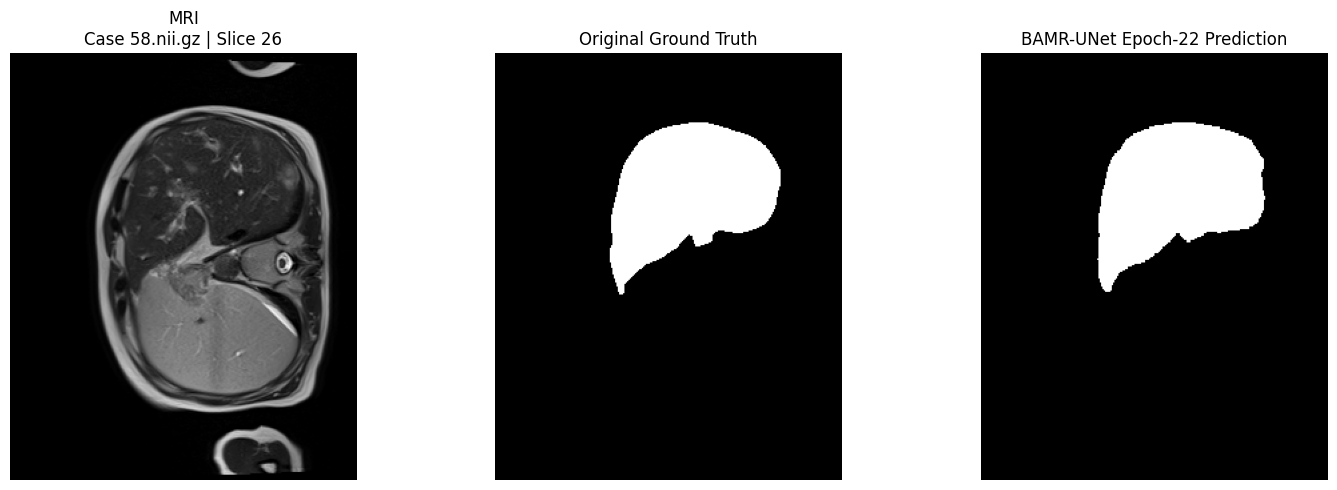

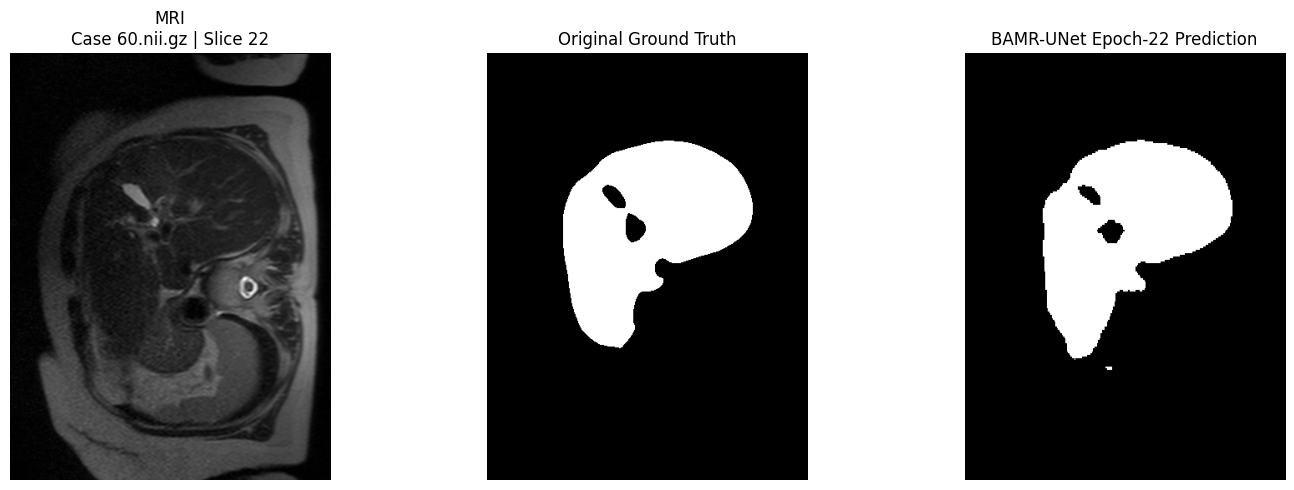

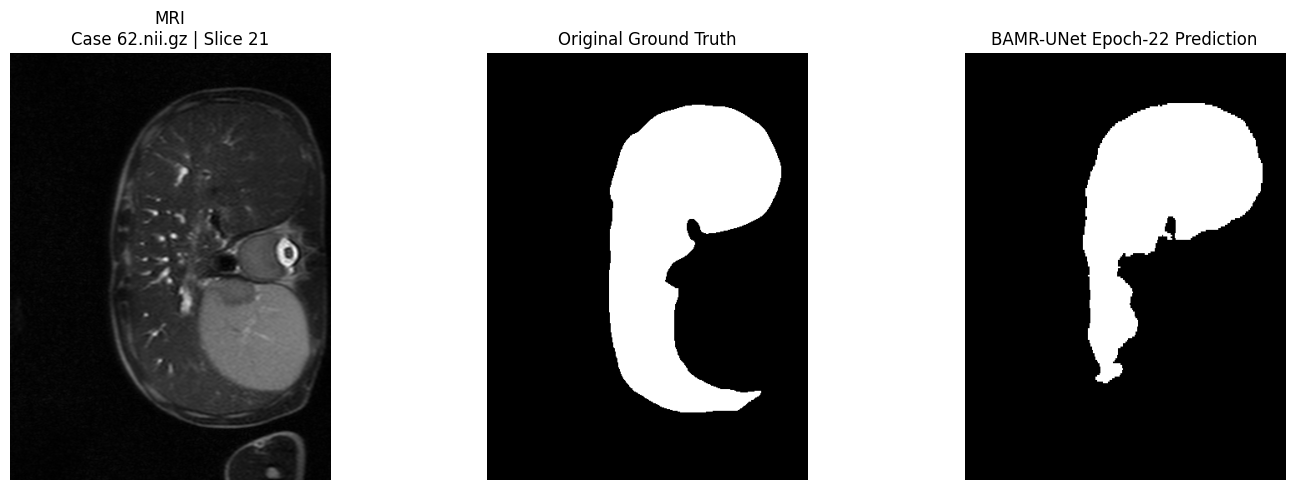


OBJECTIVE-1 VERIFICATION COMPLETE
Final Epoch-22 predictions verified.
Training performed during verification: NO
Learning performed during verification: NO
Test data used for training: NO
Predicted masks modified: NO

This verification only compared
the already-saved frozen predictions
against the original test ground-truth masks.


In [ ]:
# ================================================================
# OBJECTIVE-1 FINAL VERIFICATION
# FROZEN EPOCH-22 TEST PREDICTIONS
# METRICS + GEOMETRY CHECK + VISUAL INSPECTION
# ================================================================

import os
from pathlib import Path

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# 1. PATHS
# ================================================================

# IMPORTANT:
# This is the FINAL Epoch-22 prediction directory.
# Do NOT change this to the older predicted_test_masks directory.

PRED_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/"
    "BAMR_UNet_T2_V2_FINAL_EPOCH22/"
    "predicted_test_masks"
)

GT_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/"
    "Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_masks"
)

IMG_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/"
    "Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images"
)

OUTPUT_CSV = (
    PRED_DIR.parent /
    "BAMR_UNet_T2_V2_EPOCH22_VERIFICATION.csv"
)


# ================================================================
# 2. INITIAL CHECK
# ================================================================

print("=" * 80)
print("OBJECTIVE-1 FINAL VERIFICATION")
print("FROZEN BAMR-UNET EPOCH-22")
print("=" * 80)

print("Prediction directory :", PRED_DIR)
print("Exists                :", PRED_DIR.exists())

print("Ground-truth directory:", GT_DIR)
print("Exists                :", GT_DIR.exists())

print("Test image directory  :", IMG_DIR)
print("Exists                :", IMG_DIR.exists())


if not PRED_DIR.exists():
    raise FileNotFoundError(
        f"\nFINAL prediction directory not found:\n{PRED_DIR}"
    )

if not GT_DIR.exists():
    raise FileNotFoundError(
        f"\nGround-truth directory not found:\n{GT_DIR}"
    )

if not IMG_DIR.exists():
    raise FileNotFoundError(
        f"\nTest-image directory not found:\n{IMG_DIR}"
    )


# ================================================================
# 3. FIND FILES
# ================================================================

def get_nii_files(directory):

    files = list(directory.glob("*.nii.gz"))
    files += list(directory.glob("*.nii"))

    # Remove duplicates
    return sorted(set(files))


pred_files = get_nii_files(PRED_DIR)
gt_files = get_nii_files(GT_DIR)
img_files = get_nii_files(IMG_DIR)


print("\n" + "=" * 80)
print("FILE COUNTS")
print("=" * 80)

print("Predicted masks :", len(pred_files))
print("Ground-truth    :", len(gt_files))
print("Test images     :", len(img_files))


if len(pred_files) != 31:
    print(
        f"\nWARNING: Expected 31 predicted masks, "
        f"but found {len(pred_files)}."
    )

if len(gt_files) != 31:
    print(
        f"\nWARNING: Expected 31 GT masks, "
        f"but found {len(gt_files)}."
    )

if len(img_files) != 31:
    print(
        f"\nWARNING: Expected 31 test images, "
        f"but found {len(img_files)}."
    )


# ================================================================
# 4. MATCH CASES
# ================================================================

pred_map = {p.name: p for p in pred_files}
gt_map = {p.name: p for p in gt_files}
img_map = {p.name: p for p in img_files}

common_ids = sorted(
    set(pred_map.keys())
    &
    set(gt_map.keys())
    &
    set(img_map.keys())
)


print("\n" + "=" * 80)
print("CASE MATCHING")
print("=" * 80)

print("Matched cases:", len(common_ids))

if len(common_ids) != 31:
    print("WARNING: Expected 31 matched cases.")

print("\nMatched case names:")
print(common_ids)


# ================================================================
# 5. METRIC FUNCTIONS
# ================================================================

def dice_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()

    return (
        2.0 * intersection /
        (pred.sum() + gt.sum() + 1e-8)
    )


def iou_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    return intersection / (union + 1e-8)


def precision_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()

    return tp / (tp + fp + 1e-8)


def recall_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fn = np.logical_and(~pred, gt).sum()

    return tp / (tp + fn + 1e-8)


def specificity_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tn = np.logical_and(~pred, ~gt).sum()
    fp = np.logical_and(pred, ~gt).sum()

    return tn / (tn + fp + 1e-8)


# ================================================================
# 6. VERIFY SAVED PREDICTIONS
# ================================================================

results = []

print("\n" + "=" * 80)
print("VERIFYING SAVED EPOCH-22 PREDICTIONS")
print("=" * 80)

for i, case_id in enumerate(common_ids):

    pred_path = pred_map[case_id]
    gt_path = gt_map[case_id]

    pred_nii = nib.load(str(pred_path))
    gt_nii = nib.load(str(gt_path))

    pred = pred_nii.get_fdata()
    gt = gt_nii.get_fdata()

    # ------------------------------------------------------------
    # Binary conversion
    # ------------------------------------------------------------

    pred = pred > 0
    gt = gt > 0

    # ------------------------------------------------------------
    # Geometry check
    # ------------------------------------------------------------

    same_shape = pred.shape == gt.shape

    if not same_shape:

        print(
            "\nSHAPE MISMATCH:",
            case_id
        )

        print(
            "Prediction:",
            pred.shape
        )

        print(
            "Ground truth:",
            gt.shape
        )

        continue

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------

    dice = dice_score(pred, gt)
    iou = iou_score(pred, gt)
    precision = precision_score(pred, gt)
    recall = recall_score(pred, gt)
    specificity = specificity_score(pred, gt)

    pred_voxels = int(pred.sum())
    gt_voxels = int(gt.sum())

    results.append({

        "case": case_id,

        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,

        "pred_voxels": pred_voxels,
        "gt_voxels": gt_voxels,

        "shape": str(pred.shape),
        "same_shape": same_shape
    })

    print(
        f"{i+1:02d}/31 | "
        f"{case_id:15s} | "
        f"Dice={dice:.4f} | "
        f"IoU={iou:.4f} | "
        f"Recall={recall:.4f}"
    )


# ================================================================
# 7. CREATE DATAFRAME
# ================================================================

results_df = pd.DataFrame(results)


# ================================================================
# 8. FINAL VERIFICATION RESULTS
# ================================================================

print("\n" + "=" * 80)
print("EPOCH-22 SAVED-PREDICTION VERIFICATION RESULTS")
print("=" * 80)

print("Valid cases:", len(results_df))


if len(results_df) > 0:

    metrics = [
        "dice",
        "iou",
        "precision",
        "recall",
        "specificity"
    ]

    print("\nMean ± SD")

    for metric in metrics:

        mean_value = results_df[metric].mean()
        std_value = results_df[metric].std()

        print(
            f"{metric:12s}: "
            f"{mean_value:.4f} ± {std_value:.4f}"
        )

    print("\nPercentage form")

    for metric in metrics:

        mean_value = results_df[metric].mean() * 100
        std_value = results_df[metric].std() * 100

        print(
            f"{metric:12s}: "
            f"{mean_value:.2f}% ± {std_value:.2f}%"
        )

    # ------------------------------------------------------------
    # Dice statistics
    # ------------------------------------------------------------

    zero_dice = int(
        (results_df["dice"] <= 1e-8).sum()
    )

    perfect_dice = int(
        (results_df["dice"] >= 0.999999).sum()
    )

    print("\nDice range:")
    print(
        f"Minimum: {results_df['dice'].min():.4f}"
    )

    print(
        f"Maximum: {results_df['dice'].max():.4f}"
    )

    print(
        f"Zero-Dice cases: {zero_dice}"
    )

    print(
        f"Perfect-Dice cases: {perfect_dice}"
    )


# ================================================================
# 9. SAVE VERIFICATION CSV
# ================================================================

results_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n" + "=" * 80)
print("VERIFICATION CSV SAVED")
print("=" * 80)

print(OUTPUT_CSV)


# ================================================================
# 10. VISUAL INSPECTION
# ================================================================

print("\n" + "=" * 80)
print("VISUAL INSPECTION")
print("=" * 80)

print(
    "Displaying 3 representative test cases."
)

visual_cases = common_ids[:3]


for case_id in visual_cases:

    image_path = img_map[case_id]
    gt_path = gt_map[case_id]
    pred_path = pred_map[case_id]

    image = nib.load(
        str(image_path)
    ).get_fdata()

    gt = nib.load(
        str(gt_path)
    ).get_fdata()

    pred = nib.load(
        str(pred_path)
    ).get_fdata()

    # ------------------------------------------------------------
    # Geometry
    # ------------------------------------------------------------

    if (
        image.shape != gt.shape
        or
        gt.shape != pred.shape
    ):

        print(
            f"Skipping {case_id}: geometry mismatch."
        )

        continue

    # ------------------------------------------------------------
    # Select slice with largest GT liver area
    # ------------------------------------------------------------

    gt_areas = np.sum(
        gt > 0,
        axis=(0, 1)
    )

    z = int(
        np.argmax(gt_areas)
    )

    # ------------------------------------------------------------
    # Convert prediction / GT to binary
    # ------------------------------------------------------------

    gt_binary = gt[:, :, z] > 0
    pred_binary = pred[:, :, z] > 0

    image_slice = image[:, :, z]

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        image_slice,
        cmap="gray"
    )

    axes[0].set_title(
        f"MRI\nCase {case_id} | Slice {z}"
    )

    axes[0].axis("off")


    axes[1].imshow(
        gt_binary,
        cmap="gray"
    )

    axes[1].set_title(
        "Original Ground Truth"
    )

    axes[1].axis("off")


    axes[2].imshow(
        pred_binary,
        cmap="gray"
    )

    axes[2].set_title(
        "BAMR-UNet Epoch-22 Prediction"
    )

    axes[2].axis("off")


    plt.tight_layout()
    plt.show()


# ================================================================
# 11. FINAL STATUS
# ================================================================

print("\n" + "=" * 80)
print("OBJECTIVE-1 VERIFICATION COMPLETE")
print("=" * 80)

print("Final Epoch-22 predictions verified.")
print("Training performed during verification: NO")
print("Learning performed during verification: NO")
print("Test data used for training: NO")
print("Predicted masks modified: NO")

print("\nThis verification only compared")
print("the already-saved frozen predictions")
print("against the original test ground-truth masks.")

print("=" * 80)

OBJECTIVE-1 FINAL VERIFICATION
FROZEN BAMR-UNET EPOCH-22
Prediction directory : /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/predicted_test_masks
Ground-truth directory: /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_masks
Test-image directory  : /content/drive/MyDrive/CirrMRI_dataset/Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images

Prediction directory exists : True
Ground-truth directory exists: True
Test-image directory exists  : True

FILE COUNTS
Predicted masks: 31
Ground-truth  : 31
Test images   : 31
Matched cases : 31
31/31 test volumes matched successfully.

FINAL VOLUME-LEVEL VERIFICATION
Valid volumes: 31
Shape errors : 0
Affine warnings: 0
Empty predictions: 0

FINAL METRICS
--------------------------------------------------------------------------------
dice        : 0.9233 ± 0.0335   (92.33% ± 3.35%)
iou         : 0.8592 ± 0.0550   (85.92% ± 5.50%)
precision   : 0.9060 ± 0.0369   (90.60% ± 3.69%

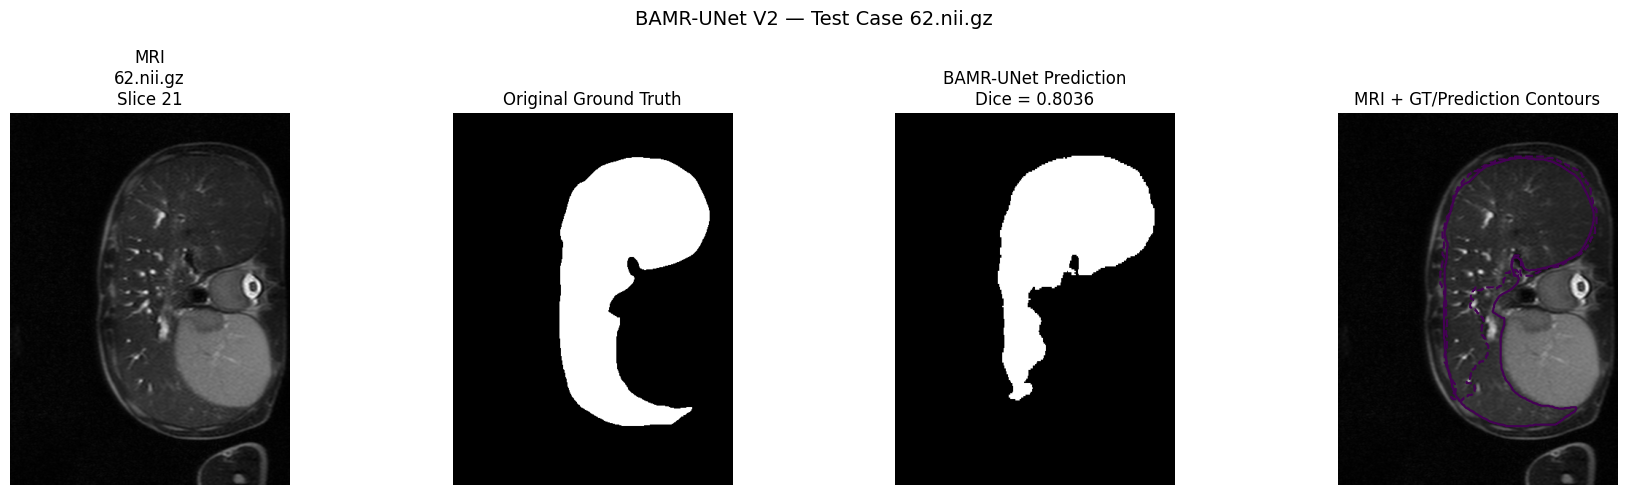

Saved: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/final_visualizations/BAMR_UNet_Epoch22_62.png


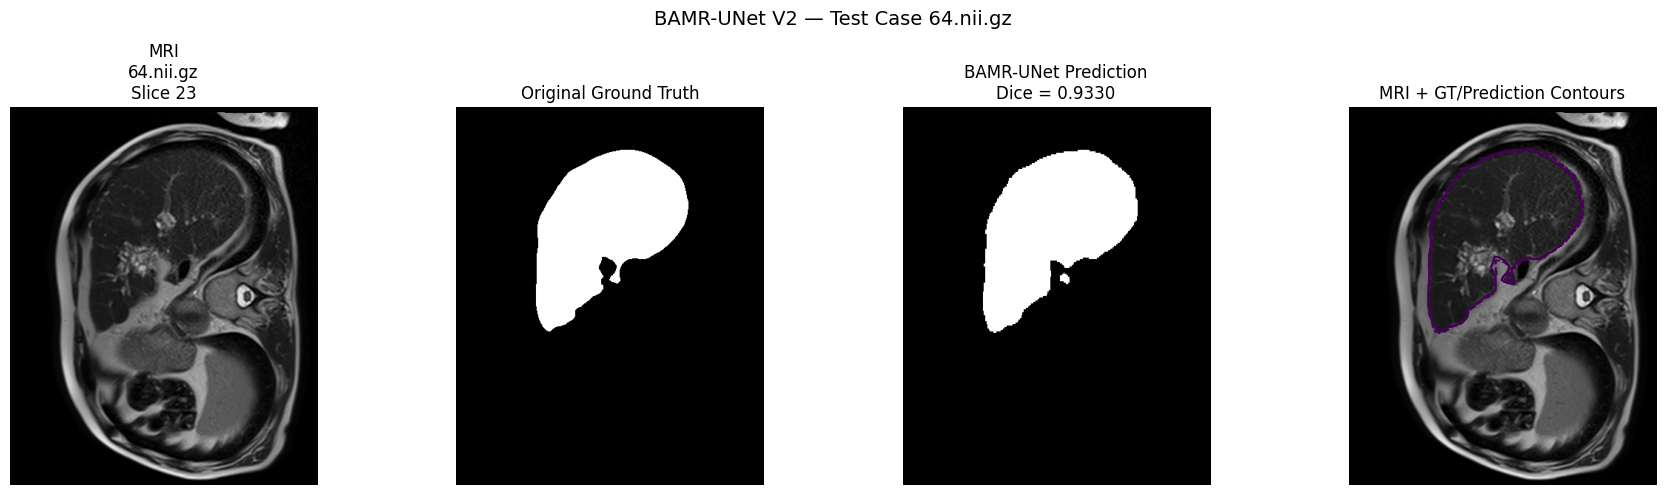

Saved: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/final_visualizations/BAMR_UNet_Epoch22_64.png


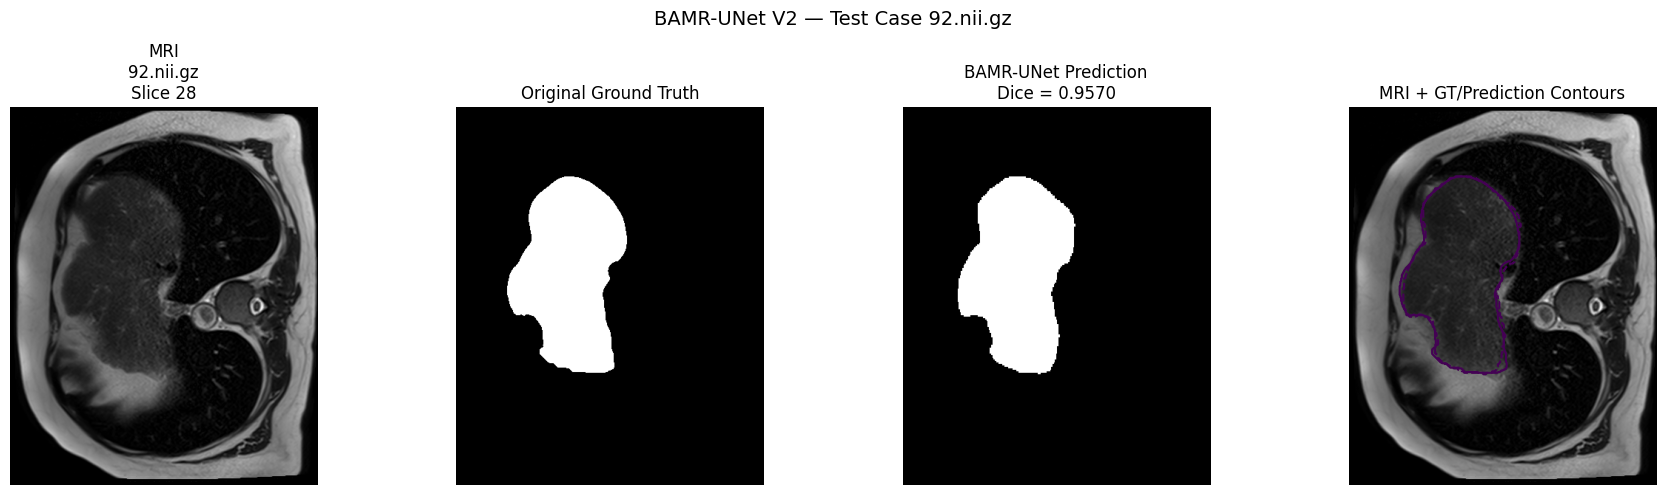

Saved: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/final_visualizations/BAMR_UNet_Epoch22_92.png


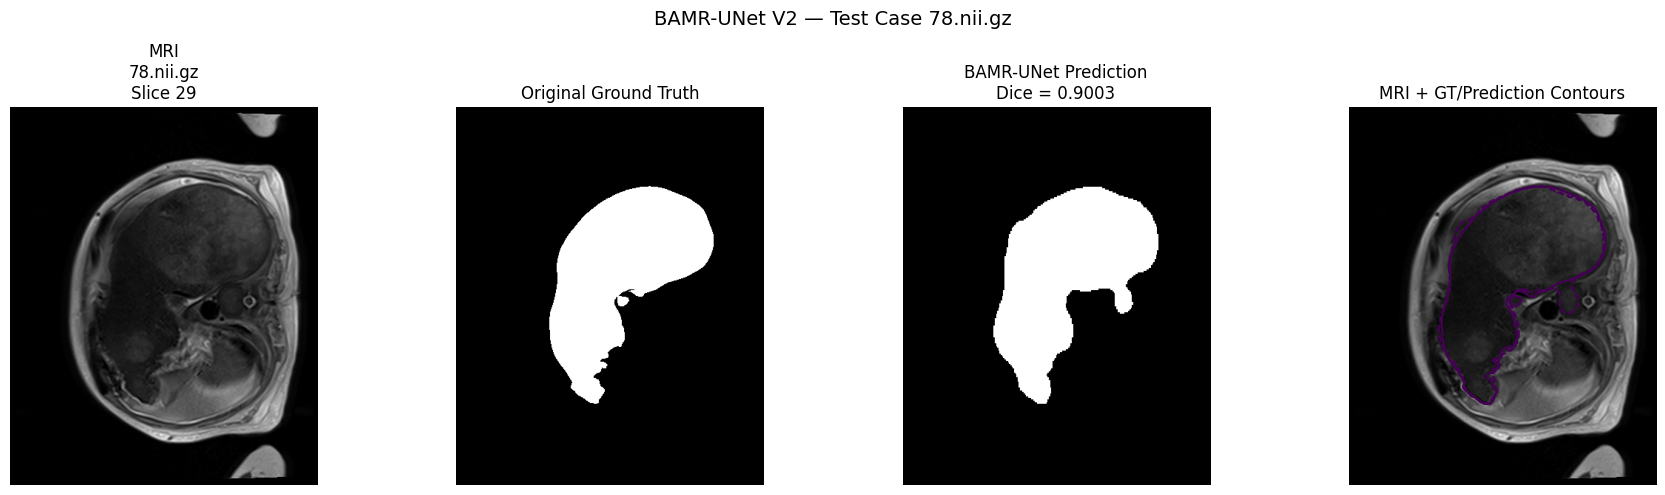

Saved: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/final_visualizations/BAMR_UNet_Epoch22_78.png


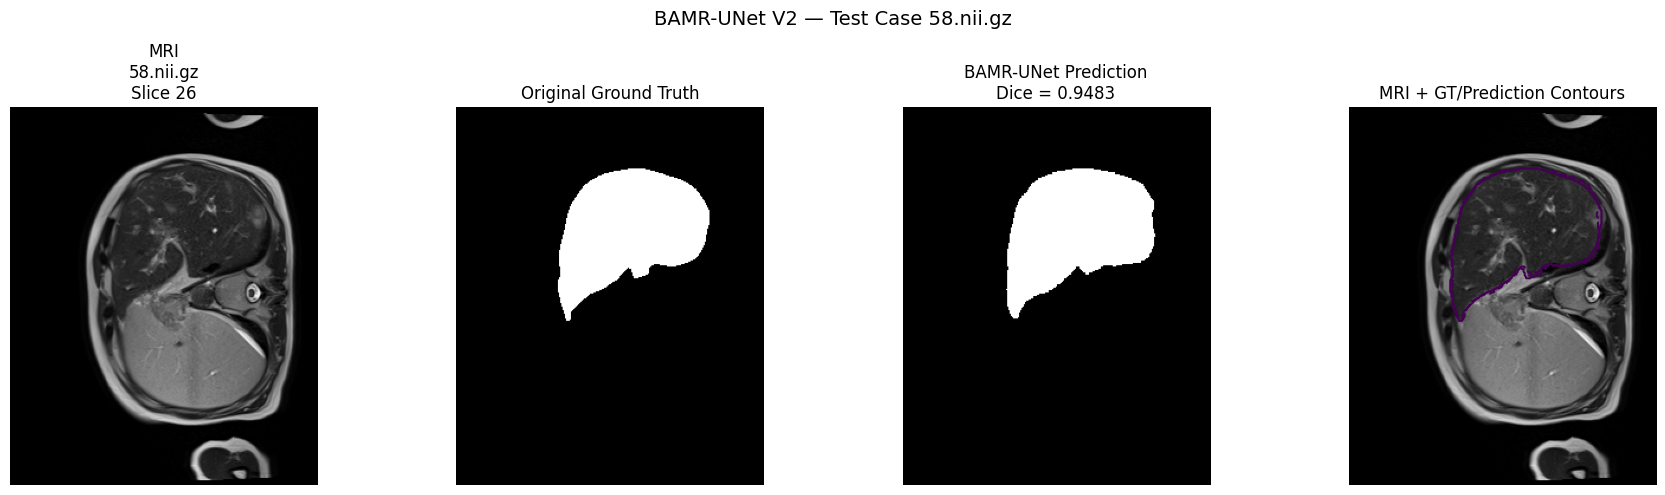

Saved: /content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/final_visualizations/BAMR_UNet_Epoch22_58.png

OBJECTIVE-1 FINAL VERIFICATION COMPLETE
Checkpoint used       : EPOCH 22
Training during test : NO
Test learning        : NO
Optimizer             : NO
Gradients             : NO
Test volumes          : 31
Predictions verified  : True
Shape errors          : 0
Empty predictions     : 0

Final verification CSV:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/BAMR_UNet_T2_V2_epoch22_VERIFICATION.csv

Final visualizations:
/content/drive/MyDrive/CirrMRI_Final_Study/Objective_1_Segmentation/BAMR_UNet_T2_V2_FINAL_EPOCH22/final_visualizations

STATUS: OBJECTIVE-1 READY FOR PAPER REPORTING


In [ ]:
# =====================================================================
# OBJECTIVE-1 FINAL VERIFICATION
# FROZEN EPOCH-22 TEST PREDICTIONS
# METRICS + GEOMETRY + VALUES + VISUALIZATION
# =====================================================================

import os
from pathlib import Path

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. PATHS — USE FINAL EPOCH-22 RESULTS
# =====================================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_Final_Study/"
    "Objective_1_Segmentation/"
    "BAMR_UNet_T2_V2_FINAL_EPOCH22"
)

PRED_DIR = BASE_DIR / "predicted_test_masks"

GT_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/"
    "Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_masks"
)

IMG_DIR = Path(
    "/content/drive/MyDrive/CirrMRI_dataset/"
    "Cirrhosis_T2_3D/Cirrhosis_T2_3D/test_images"
)

VIS_DIR = BASE_DIR / "final_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("OBJECTIVE-1 FINAL VERIFICATION")
print("FROZEN BAMR-UNET EPOCH-22")
print("=" * 80)

print("Prediction directory :", PRED_DIR)
print("Ground-truth directory:", GT_DIR)
print("Test-image directory  :", IMG_DIR)
print()

print("Prediction directory exists :", PRED_DIR.exists())
print("Ground-truth directory exists:", GT_DIR.exists())
print("Test-image directory exists  :", IMG_DIR.exists())

# =====================================================================
# 2. FIND FILES
# =====================================================================

def get_nii_files(directory):
    return sorted(
        list(directory.glob("*.nii.gz")) +
        list(directory.glob("*.nii"))
    )

pred_files = get_nii_files(PRED_DIR)
gt_files = get_nii_files(GT_DIR)
img_files = get_nii_files(IMG_DIR)

print()
print("=" * 80)
print("FILE COUNTS")
print("=" * 80)

print("Predicted masks:", len(pred_files))
print("Ground-truth  :", len(gt_files))
print("Test images   :", len(img_files))

# =====================================================================
# 3. MATCH CASES BY FILENAME
# =====================================================================

pred_map = {p.name: p for p in pred_files}
gt_map   = {p.name: p for p in gt_files}
img_map  = {p.name: p for p in img_files}

common_ids = sorted(
    set(pred_map.keys()) &
    set(gt_map.keys()) &
    set(img_map.keys())
)

print("Matched cases :", len(common_ids))

if len(common_ids) != 31:
    print("WARNING: Expected 31 matched test volumes.")

else:
    print("31/31 test volumes matched successfully.")

# =====================================================================
# 4. METRIC FUNCTIONS
# =====================================================================

def dice_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()

    return (
        2.0 * intersection /
        (pred.sum() + gt.sum() + 1e-8)
    )


def iou_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    return intersection / (union + 1e-8)


def precision_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()

    return tp / (tp + fp + 1e-8)


def recall_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fn = np.logical_and(~pred, gt).sum()

    return tp / (tp + fn + 1e-8)


def specificity_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tn = np.logical_and(~pred, ~gt).sum()
    fp = np.logical_and(pred, ~gt).sum()

    return tn / (tn + fp + 1e-8)

# =====================================================================
# 5. FINAL VERIFICATION
# =====================================================================

results = []

shape_errors = []
affine_warnings = []
empty_predictions = []

for case_id in common_ids:

    pred_nii = nib.load(str(pred_map[case_id]))
    gt_nii   = nib.load(str(gt_map[case_id]))
    img_nii  = nib.load(str(img_map[case_id]))

    pred_raw = pred_nii.get_fdata()
    gt_raw   = gt_nii.get_fdata()
    img_raw  = img_nii.get_fdata()

    # -------------------------------------------------------------
    # Binary masks
    # -------------------------------------------------------------

    pred = pred_raw > 0
    gt   = gt_raw > 0

    # -------------------------------------------------------------
    # Geometry checks
    # -------------------------------------------------------------

    if pred.shape != gt.shape:
        shape_errors.append(
            (case_id, pred.shape, gt.shape)
        )
        continue

    if img_raw.shape != gt.shape:
        shape_errors.append(
            (case_id, img_raw.shape, gt.shape)
        )
        continue

    # -------------------------------------------------------------
    # Affine check
    # -------------------------------------------------------------

    if not np.allclose(
        pred_nii.affine,
        gt_nii.affine,
        atol=1e-3
    ):
        affine_warnings.append(case_id)

    # -------------------------------------------------------------
    # Prediction-value check
    # -------------------------------------------------------------

    unique_pred = np.unique(pred_raw)

    if pred.sum() == 0:
        empty_predictions.append(case_id)

    # -------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------

    results.append({
        "case": case_id,
        "dice": dice_score(pred, gt),
        "iou": iou_score(pred, gt),
        "precision": precision_score(pred, gt),
        "recall": recall_score(pred, gt),
        "specificity": specificity_score(pred, gt),
        "pred_voxels": int(pred.sum()),
        "gt_voxels": int(gt.sum()),
        "shape": str(pred.shape),
        "prediction_unique_values": str(unique_pred.tolist())
    })

# =====================================================================
# 6. RESULTS TABLE
# =====================================================================

results_df = pd.DataFrame(results)

print()
print("=" * 80)
print("FINAL VOLUME-LEVEL VERIFICATION")
print("=" * 80)

print("Valid volumes:", len(results_df))
print("Shape errors :", len(shape_errors))
print("Affine warnings:", len(affine_warnings))
print("Empty predictions:", len(empty_predictions))

if len(empty_predictions) > 0:
    print("Empty prediction cases:")
    print(empty_predictions)

# =====================================================================
# 7. CALCULATE MEAN ± SD
# =====================================================================

metrics = [
    "dice",
    "iou",
    "precision",
    "recall",
    "specificity"
]

print()
print("FINAL METRICS")
print("-" * 80)

for metric in metrics:

    mean_value = results_df[metric].mean()
    std_value = results_df[metric].std()

    print(
        f"{metric:12s}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
        f"   ({mean_value*100:.2f}% ± {std_value*100:.2f}%)"
    )

# =====================================================================
# 8. BEST / WORST CASE
# =====================================================================

best_case = results_df.loc[
    results_df["dice"].idxmax()
]

worst_case = results_df.loc[
    results_df["dice"].idxmin()
]

print()
print("=" * 80)
print("BEST / WORST TEST VOLUMES")
print("=" * 80)

print(
    "Best case :",
    best_case["case"],
    "| Dice =",
    f"{best_case['dice']:.4f}"
)

print(
    "Worst case:",
    worst_case["case"],
    "| Dice =",
    f"{worst_case['dice']:.4f}"
)

print(
    "Zero-Dice volumes:",
    int((results_df["dice"] == 0).sum())
)

# =====================================================================
# 9. SAVE VERIFICATION CSV
# =====================================================================

verification_csv = BASE_DIR / (
    "BAMR_UNet_T2_V2_epoch22_VERIFICATION.csv"
)

results_df.to_csv(
    verification_csv,
    index=False
)

print()
print("Verification CSV saved:")
print(verification_csv)

# =====================================================================
# 10. SAVE FINAL SUMMARY
# =====================================================================

summary_txt = BASE_DIR / (
    "BAMR_UNet_T2_V2_epoch22_VERIFICATION_SUMMARY.txt"
)

with open(summary_txt, "w") as f:

    f.write("=" * 80 + "\n")
    f.write("OBJECTIVE-1 FINAL VERIFICATION SUMMARY\n")
    f.write("FROZEN BAMR-UNET EPOCH-22\n")
    f.write("=" * 80 + "\n\n")

    f.write("Model: BAMR-UNet V2\n")
    f.write("Modality: T2 MRI\n")
    f.write("Checkpoint epoch: 22\n")
    f.write("Training during inference: NO\n")
    f.write("Learning during inference: NO\n")
    f.write("Optimizer during inference: NO\n")
    f.write("Gradients during inference: NO\n")
    f.write("Test data used for training: NO\n\n")

    f.write(f"Test volumes: {len(results_df)}\n")
    f.write(f"Shape errors: {len(shape_errors)}\n")
    f.write(f"Affine warnings: {len(affine_warnings)}\n")
    f.write(f"Empty predictions: {len(empty_predictions)}\n\n")

    for metric in metrics:

        mean_value = results_df[metric].mean()
        std_value = results_df[metric].std()

        f.write(
            f"{metric}: "
            f"{mean_value:.6f} ± {std_value:.6f}\n"
        )

    f.write("\n")
    f.write(
        f"Best Dice: {best_case['dice']:.6f} "
        f"({best_case['case']})\n"
    )

    f.write(
        f"Worst Dice: {worst_case['dice']:.6f} "
        f"({worst_case['case']})\n"
    )

    f.write(
        f"Zero-Dice volumes: "
        f"{int((results_df['dice'] == 0).sum())}\n"
    )

print()
print("Summary saved:")
print(summary_txt)

# =====================================================================
# 11. VISUALIZATION
# MRI | GROUND TRUTH | PREDICTION | OVERLAY
# =====================================================================

print()
print("=" * 80)
print("GENERATING FINAL VISUALIZATIONS")
print("=" * 80)

# Select:
# 1. Best Dice
# 2. Worst Dice
# 3. Median Dice
# 4. Additional representative cases

sorted_results = results_df.sort_values("dice").reset_index(drop=True)

selected_cases = []

# Worst
selected_cases.append(sorted_results.iloc[0]["case"])

# Median
selected_cases.append(
    sorted_results.iloc[len(sorted_results) // 2]["case"]
)

# Best
selected_cases.append(sorted_results.iloc[-1]["case"])

# Add two representative cases if available
if len(sorted_results) >= 5:
    selected_cases.append(sorted_results.iloc[len(sorted_results) // 4]["case"])
    selected_cases.append(sorted_results.iloc[(3 * len(sorted_results)) // 4]["case"])

# Remove duplicates while preserving order
selected_cases = list(dict.fromkeys(selected_cases))

print("Selected cases:")
for c in selected_cases:
    print(" -", c)

# =====================================================================
# 12. CREATE FIGURES
# =====================================================================

for case_id in selected_cases:

    image = nib.load(
        str(img_map[case_id])
    ).get_fdata()

    gt = nib.load(
        str(gt_map[case_id])
    ).get_fdata()

    pred = nib.load(
        str(pred_map[case_id])
    ).get_fdata()

    gt_binary = gt > 0
    pred_binary = pred > 0

    # -------------------------------------------------------------
    # Select slice with largest GT liver area
    # -------------------------------------------------------------

    areas = [
        np.sum(gt_binary[:, :, z])
        for z in range(gt_binary.shape[2])
    ]

    z = int(np.argmax(areas))

    # -------------------------------------------------------------
    # Metrics for this case
    # -------------------------------------------------------------

    case_row = results_df[
        results_df["case"] == case_id
    ].iloc[0]

    dice = case_row["dice"]

    # -------------------------------------------------------------
    # Figure
    # -------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(18, 5)
    )

    # MRI
    axes[0].imshow(
        image[:, :, z],
        cmap="gray"
    )
    axes[0].set_title(
        f"MRI\n{case_id}\nSlice {z}"
    )
    axes[0].axis("off")

    # Ground Truth
    axes[1].imshow(
        gt_binary[:, :, z],
        cmap="gray"
    )
    axes[1].set_title(
        "Original Ground Truth"
    )
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(
        pred_binary[:, :, z],
        cmap="gray"
    )
    axes[2].set_title(
        f"BAMR-UNet Prediction\nDice = {dice:.4f}"
    )
    axes[2].axis("off")

    # Overlay
    axes[3].imshow(
        image[:, :, z],
        cmap="gray"
    )

    # GT contour
    axes[3].contour(
        gt_binary[:, :, z],
        levels=[0.5],
        linewidths=1.5
    )

    # Prediction contour
    axes[3].contour(
        pred_binary[:, :, z],
        levels=[0.5],
        linewidths=1.5,
        linestyles="--"
    )

    axes[3].set_title(
        "MRI + GT/Prediction Contours"
    )
    axes[3].axis("off")

    plt.suptitle(
        f"BAMR-UNet V2 — Test Case {case_id}",
        fontsize=14
    )

    plt.tight_layout()

    save_path = VIS_DIR / (
        f"BAMR_UNet_Epoch22_{case_id.replace('.nii.gz','')}.png"
    )

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", save_path)

# =====================================================================
# 13. FINAL STATUS
# =====================================================================

print()
print("=" * 80)
print("OBJECTIVE-1 FINAL VERIFICATION COMPLETE")
print("=" * 80)

print("Checkpoint used       : EPOCH 22")
print("Training during test : NO")
print("Test learning        : NO")
print("Optimizer             : NO")
print("Gradients             : NO")
print("Test volumes          :", len(results_df))
print("Predictions verified  :", len(results_df) == 31)
print("Shape errors          :", len(shape_errors))
print("Empty predictions     :", len(empty_predictions))
print()
print("Final verification CSV:")
print(verification_csv)
print()
print("Final visualizations:")
print(VIS_DIR)
print()
print("STATUS: OBJECTIVE-1 READY FOR PAPER REPORTING")